可视化重建结果

Lead  0 days: RMSE = 1.2702, PCC = 0.9156
Lead  2 days: RMSE = 1.3226, PCC = 0.9066
Lead  4 days: RMSE = 1.4954, PCC = 0.8798
Lead  6 days: RMSE = 1.6754, PCC = 0.8450
Lead 10 days: RMSE = 2.1582, PCC = 0.7483
Lead 14 days: RMSE = 2.6019, PCC = 0.6351
Lead 18 days: RMSE = 2.3883, PCC = 0.7105


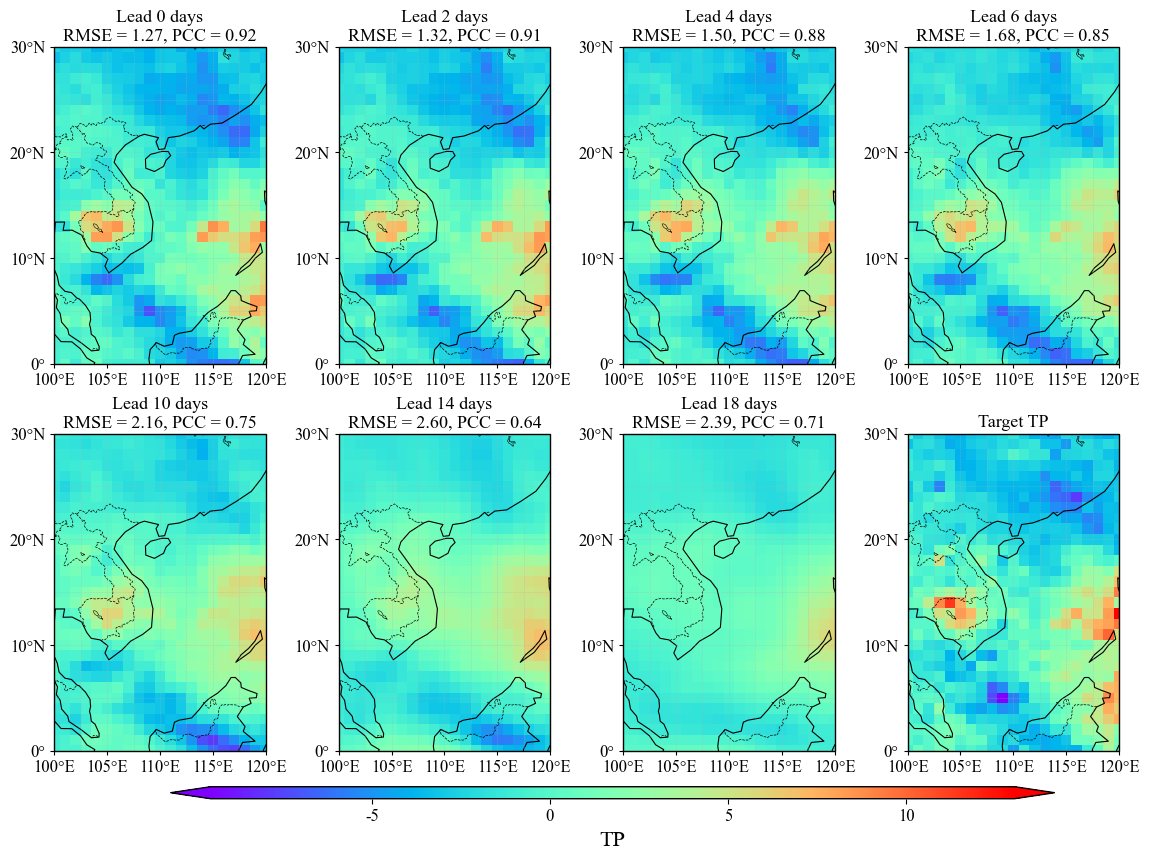

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter


# ============================================================
# 1. 全局字体设置
# ============================================================

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 11
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
plt.rcParams["mathtext.it"] = "Times New Roman:italic"
plt.rcParams["mathtext.bf"] = "Times New Roman:bold"


# ============================================================
# 2. 参数设置
# ============================================================

pred_dir = r"C:\Users\sysu\Desktop\tp_reconstruction\results\miso_dilated_se"
target_dir = r"C:\Users\sysu\Desktop\tp_reconstruction\data\test\tp"

date = "20170727"

tp_min = -30.7176074981689
tp_max = 28.9318389892578

leading_list = ["0", "2", "4", "6", "10", "14", "18"]

expected_shape = (31, 21)

# 31 × 21网格对应经纬度
lat = np.linspace(0, 30, 31)
lon = np.linspace(100, 120, 21)
lon_grid, lat_grid = np.meshgrid(lon, lat)


# ============================================================
# 3. 工具函数
# ============================================================

def denormalize(tp):
    """将[-1, 1]归一化数据恢复到原始尺度。"""
    return ((tp + 1.0) / 2.0) * (tp_max - tp_min) + tp_min


def load_tp_field(file_path, field_name):
    """读取、检查并反归一化二维TP场。"""
    if not os.path.isfile(file_path):
        raise FileNotFoundError(
            f"{field_name} file does not exist: {file_path}"
        )

    field = np.load(file_path, allow_pickle=False)
    field = np.squeeze(field)

    if field.shape != expected_shape:
        raise ValueError(
            f"{field_name} shape should be {expected_shape}, "
            f"but got {field.shape}: {file_path}"
        )

    field = field.astype(np.float64)
    field = denormalize(field)

    return field


def calculate_spatial_rmse(pred, target):
    """
    计算预测场和目标场之间的空间RMSE。
    """
    pred = np.asarray(pred, dtype=np.float64)
    target = np.asarray(target, dtype=np.float64)

    valid_mask = np.isfinite(pred) & np.isfinite(target)

    if np.sum(valid_mask) == 0:
        return float("nan")

    errors = pred[valid_mask] - target[valid_mask]

    rmse = np.sqrt(
        np.mean(errors ** 2)
    )

    return float(rmse)


def calculate_spatial_pcc(pred, target):
    """
    计算预测场和目标场之间的空间Pearson相关系数。

    将二维场展平后，仅使用两者均为有限值的格点。
    """
    pred = np.asarray(pred, dtype=np.float64).ravel()
    target = np.asarray(target, dtype=np.float64).ravel()

    valid_mask = np.isfinite(pred) & np.isfinite(target)

    pred_valid = pred[valid_mask]
    target_valid = target[valid_mask]

    if pred_valid.size < 2:
        return float("nan")

    pred_std = np.std(pred_valid)
    target_std = np.std(target_valid)

    if pred_std <= 1e-12 or target_std <= 1e-12:
        return float("nan")

    pcc = np.corrcoef(
        pred_valid,
        target_valid,
    )[0, 1]

    return float(pcc)


def set_map_format(ax):
    """统一设置每个地图子图的范围、刻度和地图要素。"""
    ax.set_extent(
        [100, 120, 0, 30],
        crs=ccrs.PlateCarree(),
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.8,
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.5,
        linestyle="--",
    )

    ax.add_feature(
        cfeature.LAKES,
        facecolor="none",
        edgecolor="black",
        linewidth=0.4,
    )

    ax.set_xticks(
        [100, 105, 110, 115, 120],
        crs=ccrs.PlateCarree(),
    )

    ax.set_yticks(
        [0, 10, 20, 30],
        crs=ccrs.PlateCarree(),
    )

    ax.xaxis.set_major_formatter(
        LongitudeFormatter()
    )

    ax.yaxis.set_major_formatter(
        LatitudeFormatter()
    )

    ax.tick_params(
        axis="both",
        labelsize=12,
        direction="out",
        length=3,
        labelfontfamily="Times New Roman",
    )

    ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,
        linewidth=0.4,
        linestyle="--",
        alpha=0.5,
    )


# ============================================================
# 4. 读取目标场
# ============================================================

target_path = os.path.join(
    target_dir,
    f"{date}.npy",
)

tp_target = load_tp_field(
    target_path,
    field_name="Target",
)

# 将数组翻转，使纬度方向与0–30°N一致
tp_target = tp_target[::-1]

# 所有子图统一使用目标场的颜色范围
vmin = np.nanmin(tp_target)
vmax = np.nanmax(tp_target)

if not np.isfinite(vmin) or not np.isfinite(vmax):
    raise ValueError(
        f"Invalid target color range: vmin={vmin}, vmax={vmax}"
    )

if vmax <= vmin:
    raise ValueError(
        f"Target field has no valid range: vmin={vmin}, vmax={vmax}"
    )


# ============================================================
# 5. 创建地图子图
# ============================================================

projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    2,
    4,
    figsize=(13, 8),
    subplot_kw={"projection": projection},
)

axes = axes.ravel()

image = None


# ============================================================
# 6. 绘制不同leading结果
# ============================================================

for index, leading in enumerate(leading_list):
    ax = axes[index]

    pred_path = os.path.join(
        pred_dir,
        f"leading{leading}",
        f"{date}.npy",
    )

    tp_pred = load_tp_field(
        pred_path,
        field_name=f"Leading {leading} prediction",
    )

    # 纬度方向翻转
    tp_pred = tp_pred[::-1]

    # 计算空间RMSE和PCC
    rmse = calculate_spatial_rmse(
        tp_pred,
        tp_target,
    )

    pcc = calculate_spatial_pcc(
        tp_pred,
        tp_target,
    )

    image = ax.pcolormesh(
        lon_grid,
        lat_grid,
        tp_pred,
        cmap="rainbow",
        vmin=vmin,
        vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )

    set_map_format(ax)

    ax.set_title(
        f"Lead {leading} days\n"
        f"RMSE = {rmse:.2f}, PCC = {pcc:.2f}",
        fontsize=13,
        pad=5,
        fontname="Times New Roman",
    )

    print(
        f"Lead {leading:>2} days: "
        f"RMSE = {rmse:.4f}, "
        f"PCC = {pcc:.4f}"
    )


# ============================================================
# 7. 绘制目标场
# ============================================================

ax = axes[7]

image = ax.pcolormesh(
    lon_grid,
    lat_grid,
    tp_target,
    cmap="rainbow",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
    transform=ccrs.PlateCarree(),
)

set_map_format(ax)

ax.set_title(
    "Target TP",
    fontsize=13,
    pad=5,
    fontname="Times New Roman",
)


# ============================================================
# 8. 共享颜色条
# ============================================================

fig.subplots_adjust(
    left=0.05,
    right=0.90,
    bottom=0.06,
    top=0.94,
    wspace=0.13,
    hspace=0.22,
)

colorbar_ax = fig.add_axes(
    [0.155, 0.00, 0.68, 0.015]
)

cbar = fig.colorbar(
    image,
    cax=colorbar_ax,
    extend="both",
    orientation="horizontal",
)

cbar.set_label(
    "TP",
    fontsize=16,
    fontname="Times New Roman",
)

cbar.ax.tick_params(
    labelsize=12,
    labelfontfamily="Times New Roman",
)
plt.savefig("C:/Users/sysu/Desktop/tp_reconstruction/results/figures/result_visualize.png", dpi=600, bbox_inches="tight")
plt.show()

计算全测试集误差

In [42]:
import glob
import numpy as np
import tqdm
import matplotlib.pyplot as plt
def denormalize(tp):
    return ((tp + 1)/2)*(tp_max - tp_min) + tp_min
def calculate_metrics(
    total_pred,
    total_target,
):
    """
    计算整个验证集的 MSE、MAE 和 R2。
    """
    total = total_pred.shape[0]
    mse = np.mean((total_pred - total_target)**2)
    mae = np.mean(np.abs(total_pred - total_target))
    mape = np.mean(np.abs((total_pred - total_target) / total_target))
    ss_res = np.sum((total_pred - total_target)**2)
    ss_tot = np.sum((total_target - np.mean(total_target))**2)

    if ss_tot == 0.0:
        r2 = float("nan")
    else:
        r2 = 1.0 - ss_res / ss_tot

    return mse, mae, r2, mape
tp_min = -30.7176074981689
tp_max = 28.9318389892578
leading_list = ["0","2","4","6","8","10","12","14","16","18","20"]#,"22","24","26","28"]
metrics_dict = {}
for leading in leading_list:

    pred_list = glob.glob(f'C:/Users/sysu/Desktop/tp_reconstruction/results/miso_dilated_se/leading{leading}/*.npy')
    target_dir = "C:/Users/sysu/Desktop/tp_reconstruction/data/test/tp"
    pred_list.sort()
    pred_array_list = []
    target_array_list = []
    i = 0
    for path in tqdm.tqdm(pred_list):
        date = path.split(".")[-2][-4:]
        if date < "0521":
            continue
        i+=1
        pred = np.load(path)
        target = np.load(target_dir + "/" + path.split(".")[-2][-8:] + ".npy")
        pred = denormalize(pred)
        target = denormalize(target)
        pred_array_list.append(pred)
        target_array_list.append(target)
    pred_array = np.stack(pred_array_list,axis=0)
    target_array = np.stack(target_array_list,axis=0)
    mse, mae, r2, mape = calculate_metrics(pred_array, target_array)
    metrics_dict[leading] = (mse, mae, r2, mape)
    print(f"Leading {leading}: MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}, MAPE: {mape:.4f}, Total samples: {i}")

    


100%|██████████| 738/738 [00:00<00:00, 7052.25it/s]


Leading 0: MSE: 1.1721, MAE: 0.8060, R2: 0.8699, MAPE: 3.9297, Total samples: 618


100%|██████████| 726/726 [00:00<00:00, 7799.04it/s]


Leading 2: MSE: 1.4347, MAE: 0.8874, R2: 0.8407, MAPE: 3.9016, Total samples: 618


100%|██████████| 714/714 [00:00<00:00, 7832.09it/s]


...

Leading 16: MSE: 5.6570, MAE: 1.7112, R2: 0.3721, MAPE: 4.0746, Total samples: 618


100%|██████████| 630/630 [00:00<00:00, 6563.11it/s]


Leading 18: MSE: 6.0410, MAE: 1.7711, R2: 0.3295, MAPE: 4.8455, Total samples: 618


100%|██████████| 618/618 [00:00<00:00, 6589.54it/s]

Leading 20: MSE: 6.0829, MAE: 1.7663, R2: 0.3248, MAPE: 3.9098, Total samples: 618


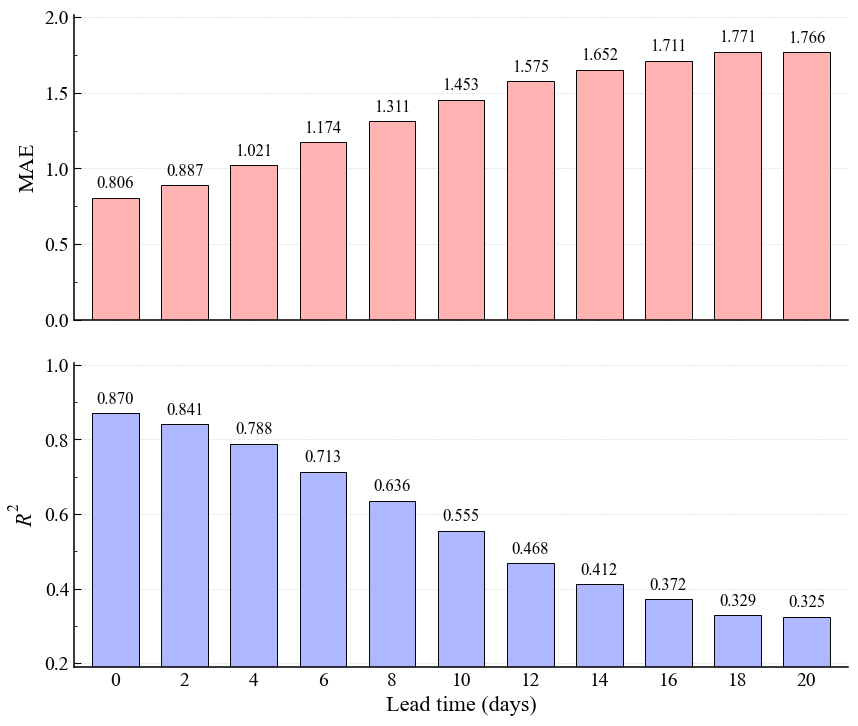

Figure saved to: C:/Users/sysu/Desktop/tp_reconstruction/results/figures\metrics_&_lead_time.png


In [43]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
# 1. 整理数据
leading_list = sorted(leading_list)
mae_array = np.asarray([metrics_dict[lead][1] for lead in leading_list], dtype=float)
r2_array = np.asarray([metrics_dict[lead][2] for lead in leading_list], dtype=float)
leading_array = np.asarray(leading_list, dtype=float)


# 2. 保存路径
save_dir = "C:/Users/sysu/Desktop/tp_reconstruction/results/figures"
save_path = os.path.join(save_dir, "metrics_&_lead_time.png")
os.makedirs(save_dir, exist_ok=True)


# 3. 全局绘图设置
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.linewidth": 1.1,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "axes.unicode_minus": False,
})


# 4. 创建图像
fig, axes = plt.subplots(2, 1, figsize=(9, 7.5), sharex=True)
ax1, ax2 = axes

bar_width = 1.35

# 5. MAE柱状图
bars1 = ax1.bar(leading_array, mae_array, width=bar_width, color="#ffb3b3", edgecolor="black", linewidth=0.7)

ax1.set_ylabel("MAE")
ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
ax1.set_axisbelow(True)
ax1.yaxis.set_minor_locator(AutoMinorLocator(2))

mae_margin = max((mae_array.max() - mae_array.min()) * 0.25, mae_array.max() * 0.12)
ax1.set_ylim(0, mae_array.max() + mae_margin)

ax1.bar_label(bars1, labels=[f"{value:.3f}" for value in mae_array], padding=4, fontsize=12)


# 6. R²柱状图
bars2 = ax2.bar(leading_array, r2_array, width=bar_width, color="#aeb7ff", edgecolor="black", linewidth=0.7)

ax2.set_xlabel("Lead time (days)")
ax2.set_ylabel(r"$R^2$")
ax2.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
ax2.set_axisbelow(True)
ax2.yaxis.set_minor_locator(AutoMinorLocator(2))

r2_margin = max((r2_array.max() - r2_array.min()) * 0.25, 0.05)
r2_lower = max(0, r2_array.min() - r2_margin)
r2_upper = min(1.05, r2_array.max() + r2_margin)
ax2.set_ylim(r2_lower, r2_upper)

ax2.bar_label(bars2, labels=[f"{value:.3f}" for value in r2_array], padding=4, fontsize=12)


# 7. 坐标轴样式
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)
    ax.tick_params(axis="both", which="both", top=False, right=False)

ax2.set_xticks(leading_array)
ax2.set_xticklabels([str(int(value)) for value in leading_array])
ax2.set_xlim(leading_array.min() - 1.2, leading_array.max() + 1.2)


# 8. 保存
fig.subplots_adjust(left=0.12, right=0.98, top=0.97, bottom=0.10, hspace=0.14)
fig.savefig(save_path, dpi=600, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Figure saved to: {save_path}")

Lead  0 days | Model: MAE=0.8060, R2=0.8699, N=618 | Persistence: MAE=0.0000, R2=1.0000, N=618
Lead  2 days | Model: MAE=0.8874, R2=0.8407, N=618 | Persistence: MAE=7.5295, R2=-0.5319, N=618
Lead  4 days | Model: MAE=1.0210, R2=0.7882, N=618 | Persistence: MAE=8.1908, R2=-0.7102, N=618
Lead  6 days | Model: MAE=1.1745, R2=0.7133, N=618 | Persistence: MAE=8.4525, R2=-0.7873, N=618
Lead  8 days | Model: MAE=1.3110, R2=0.6359, N=618 | Persistence: MAE=8.6017, R2=-0.8149, N=618
Lead 10 days | Model: MAE=1.4532, R2=0.5548, N=618 | Persistence: MAE=8.6934, R2=-0.8388, N=618
Lead 12 days | Model: MAE=1.5746, R2=0.4683, N=618 | Persistence: MAE=8.7138, R2=-0.8367, N=618
Lead 14 days | Model: MAE=1.6515, R2=0.4123, N=618 | Persistence: MAE=8.7463, R2=-0.8340, N=618
Lead 16 days | Model: MAE=1.7112, R2=0.3721, N=618 | Persistence: MAE=8.8625, R2=-0.8671, N=618
Lead 18 days | Model: MAE=1.7711, R2=0.3295, N=618 | Persistence: MAE=8.8972, R2=-0.8712, N=618
Lead 20 days | Model: MAE=1.7663, R2=0.32

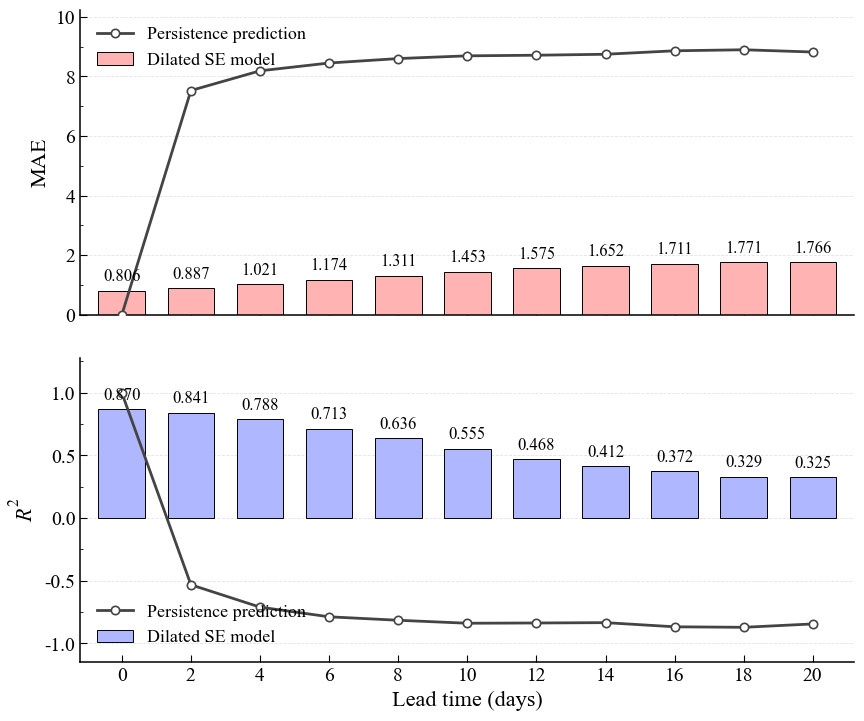


Figure saved to: C:\Users\sysu\Desktop\tp_reconstruction\results\figures\metrics_and_persistence_lead_time.png


In [40]:
import os
import glob
from datetime import datetime, timedelta

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator


# 1. 路径与参数

# 模型预测结果
MODEL_PRED_ROOT = (
    r"C:\Users\sysu\Desktop\tp_reconstruction"
    r"\results\miso_dilated_se"
)

# 模型对应的目标数据
MODEL_TARGET_DIR = (
    r"C:\Users\sysu\Desktop\tp_reconstruction"
    r"\data\test\tp"
)

# 用于Persistence预测的原始TP数据
RAW_TP_DIR = (
    r"C:\Users\sysu\Desktop\Diffusion model"
    r"\data\tp"
)

# 模型输出和模型target使用的反归一化参数
TP_MIN = -30.7176074981689
TP_MAX = 28.9318389892578

# 需要统计的lead time
LEADING_LIST = [
    "0", "2", "4", "6", "8", "10",
    "12", "14", "16", "18", "20",
]

# 与原代码保持一致，只统计5月21日及之后的样本
EVAL_START_MMDD = "0521"

# 不设置结束日期时使用None
EVAL_END_MMDD = None

# 图片保存
SAVE_DIR = (
    r"C:\Users\sysu\Desktop\tp_reconstruction"
    r"\results\figures"
)

SAVE_PATH = os.path.join(
    SAVE_DIR,
    "metrics_and_persistence_lead_time.png",
)

os.makedirs(SAVE_DIR, exist_ok=True)


# 2. Times New Roman字体设置

plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
plt.rcParams["mathtext.it"] = "Times New Roman:italic"
plt.rcParams["mathtext.bf"] = "Times New Roman:bold"

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "axes.linewidth": 1.1,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "axes.unicode_minus": False,
})


# 3. 反归一化函数

def denormalize_model_tp(data):
    """
    模型预测及模型target的反归一化：
    [-1, 1] -> 30–60天滤波信号空间。
    """
    data = np.asarray(data, dtype=np.float64)

    return (
        (data + 1.0)
        / 2.0
        * (TP_MAX - TP_MIN)
        + TP_MIN
    )


def inverse_transform_raw_tp(data):
    """
    原始TP数据反归一化：
    [-1, 1] -> log10(x+1)空间 -> 原始物理量。
    """
    data = np.asarray(data, dtype=np.float64)

    log_data = (
        (data + 1.0)
        * 2.70187
        / 2.0
    )

    original_data = (
        np.power(10.0, log_data)
        - 1.0
    )

    return original_data


# 4. 工具函数

def get_date_from_path(file_path):
    """从YYYYMMDD.npy文件名提取日期。"""
    file_name = os.path.basename(file_path)
    date_string = os.path.splitext(file_name)[0]

    datetime.strptime(
        date_string,
        "%Y%m%d",
    )

    return date_string


def date_in_evaluation_period(date_string):
    """判断日期是否位于指定的月日统计范围。"""
    mmdd = date_string[4:]

    if mmdd < EVAL_START_MMDD:
        return False

    if (
        EVAL_END_MMDD is not None
        and mmdd > EVAL_END_MMDD
    ):
        return False

    return True


def load_2d_array(file_path):
    """读取并检查二维数组。"""
    if not os.path.isfile(file_path):
        raise FileNotFoundError(
            f"File does not exist: {file_path}"
        )

    array = np.load(
        file_path,
        allow_pickle=False,
    )

    array = np.squeeze(array)

    if array.ndim != 2:
        raise ValueError(
            f"Expected a 2D array, "
            f"but got shape {array.shape}: "
            f"{file_path}"
        )

    return array.astype(
        np.float64,
        copy=False,
    )


def calculate_mae_r2(pred_array, target_array):
    """
    将全部日期和全部空间格点展开后，
    计算总体MAE和R²。
    """
    pred_array = np.asarray(
        pred_array,
        dtype=np.float64,
    )

    target_array = np.asarray(
        target_array,
        dtype=np.float64,
    )

    if pred_array.shape != target_array.shape:
        raise ValueError(
            f"Prediction and target shapes differ: "
            f"{pred_array.shape} vs "
            f"{target_array.shape}"
        )

    pred_flat = pred_array.ravel()
    target_flat = target_array.ravel()

    valid_mask = (
        np.isfinite(pred_flat)
        & np.isfinite(target_flat)
    )

    pred_valid = pred_flat[
        valid_mask
    ]

    target_valid = target_flat[
        valid_mask
    ]

    if pred_valid.size == 0:
        return float("nan"), float("nan")

    mae = np.mean(
        np.abs(
            pred_valid
            - target_valid
        )
    )

    ss_res = np.sum(
        (
            pred_valid
            - target_valid
        ) ** 2
    )

    ss_tot = np.sum(
        (
            target_valid
            - np.mean(target_valid)
        ) ** 2
    )

    if ss_tot <= 0:
        r2 = float("nan")
    else:
        r2 = (
            1.0
            - ss_res / ss_tot
        )

    return float(mae), float(r2)


# 5. 计算模型指标

def calculate_model_metrics(lead_time):
    """
    计算指定lead time下模型预测的MAE和R²。
    """
    prediction_folder = os.path.join(
        MODEL_PRED_ROOT,
        f"leading{lead_time}",
    )

    prediction_files = sorted(
        glob.glob(
            os.path.join(
                prediction_folder,
                "*.npy",
            )
        )
    )

    prediction_arrays = []
    target_arrays = []
    used_dates = []

    for prediction_path in prediction_files:
        try:
            target_date = get_date_from_path(
                prediction_path
            )
        except ValueError:
            continue

        if not date_in_evaluation_period(
            target_date
        ):
            continue

        target_path = os.path.join(
            MODEL_TARGET_DIR,
            f"{target_date}.npy",
        )

        if not os.path.isfile(target_path):
            continue

        prediction = load_2d_array(
            prediction_path
        )

        target = load_2d_array(
            target_path
        )

        if prediction.shape != target.shape:
            raise ValueError(
                f"Shape mismatch on {target_date}: "
                f"prediction={prediction.shape}, "
                f"target={target.shape}"
            )

        prediction = denormalize_model_tp(
            prediction
        )

        target = denormalize_model_tp(
            target
        )

        prediction_arrays.append(
            prediction
        )

        target_arrays.append(
            target
        )

        used_dates.append(
            target_date
        )

    if not prediction_arrays:
        raise RuntimeError(
            f"No valid model samples found for "
            f"leading{lead_time}"
        )

    prediction_arrays = np.stack(
        prediction_arrays,
        axis=0,
    )

    target_arrays = np.stack(
        target_arrays,
        axis=0,
    )

    mae, r2 = calculate_mae_r2(
        prediction_arrays,
        target_arrays,
    )

    return mae, r2, used_dates


# 6. 计算Persistence指标

def calculate_persistence_metrics(
    lead_time,
    model_target_dates,
):
    """
    Persistence定义：

        TP_persistence(t) = TP_original(t - lead_time)

    并与原始TP(t)进行比较。

    为保证样本一致，target日期使用该lead下
    模型实际参与评价的日期。
    """
    lead_time = int(
        lead_time
    )

    persistence_arrays = []
    target_arrays = []
    used_dates = []

    for target_date in model_target_dates:
        target_datetime = datetime.strptime(
            target_date,
            "%Y%m%d",
        )

        persistence_datetime = (
            target_datetime
            - timedelta(days=lead_time)
        )

        persistence_date = (
            persistence_datetime.strftime(
                "%Y%m%d"
            )
        )

        target_path = os.path.join(
            RAW_TP_DIR,
            f"{target_date}.npy",
        )

        persistence_path = os.path.join(
            RAW_TP_DIR,
            f"{persistence_date}.npy",
        )

        if (
            not os.path.isfile(target_path)
            or not os.path.isfile(
                persistence_path
            )
        ):
            continue

        target = load_2d_array(
            target_path
        )

        persistence = load_2d_array(
            persistence_path
        )

        if persistence.shape != target.shape:
            raise ValueError(
                f"Raw TP shape mismatch for "
                f"target={target_date}, "
                f"persistence={persistence_date}: "
                f"{persistence.shape} vs "
                f"{target.shape}"
            )

        target = inverse_transform_raw_tp(
            target
        )

        persistence = inverse_transform_raw_tp(
            persistence
        )

        persistence_arrays.append(
            persistence
        )

        target_arrays.append(
            target
        )

        used_dates.append(
            target_date
        )

    if not persistence_arrays:
        raise RuntimeError(
            f"No valid persistence samples found "
            f"for leading{lead_time}"
        )

    persistence_arrays = np.stack(
        persistence_arrays,
        axis=0,
    )

    target_arrays = np.stack(
        target_arrays,
        axis=0,
    )

    mae, r2 = calculate_mae_r2(
        persistence_arrays,
        target_arrays,
    )

    return mae, r2, used_dates


# 7. 计算所有lead time的指标

leading_values = sorted(
    [int(value) for value in LEADING_LIST]
)

model_mae_list = []
model_r2_list = []

persistence_mae_list = []
persistence_r2_list = []

for lead_time in leading_values:
    (
        model_mae,
        model_r2,
        model_dates,
    ) = calculate_model_metrics(
        lead_time
    )

    (
        persistence_mae,
        persistence_r2,
        persistence_dates,
    ) = calculate_persistence_metrics(
        lead_time=lead_time,
        model_target_dates=model_dates,
    )

    model_mae_list.append(
        model_mae
    )

    model_r2_list.append(
        model_r2
    )

    persistence_mae_list.append(
        persistence_mae
    )

    persistence_r2_list.append(
        persistence_r2
    )

    print(
        f"Lead {lead_time:>2} days | "
        f"Model: MAE={model_mae:.4f}, "
        f"R2={model_r2:.4f}, "
        f"N={len(model_dates)} | "
        f"Persistence: "
        f"MAE={persistence_mae:.4f}, "
        f"R2={persistence_r2:.4f}, "
        f"N={len(persistence_dates)}"
    )


# 转换成数组
leading_array = np.asarray(
    leading_values,
    dtype=float,
)

model_mae_array = np.asarray(
    model_mae_list,
    dtype=float,
)

model_r2_array = np.asarray(
    model_r2_list,
    dtype=float,
)

persistence_mae_array = np.asarray(
    persistence_mae_list,
    dtype=float,
)

persistence_r2_array = np.asarray(
    persistence_r2_list,
    dtype=float,
)


# 8. 创建图像

fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 7.5),
    sharex=True,
)

ax1, ax2 = axes

bar_width = 1.35

MODEL_MAE_COLOR = "#ffb3b3"
MODEL_R2_COLOR = "#aeb7ff"
PERSISTENCE_COLOR = "#444444"


# 9. MAE柱状图与Persistence折线

bars1 = ax1.bar(
    leading_array,
    model_mae_array,
    width=bar_width,
    color=MODEL_MAE_COLOR,
    edgecolor="black",
    linewidth=0.7,
    label="Dilated SE model",
    zorder=2,
)

ax1.plot(
    leading_array,
    persistence_mae_array,
    color=PERSISTENCE_COLOR,
    marker="o",
    markersize=6,
    markerfacecolor="white",
    markeredgecolor=PERSISTENCE_COLOR,
    markeredgewidth=1.2,
    linewidth=2.0,
    label="Persistence prediction",
    zorder=3,
)

ax1.set_ylabel("MAE")

ax1.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35,
)

ax1.set_axisbelow(True)

ax1.yaxis.set_minor_locator(
    AutoMinorLocator(2)
)

# 同时考虑模型与Persistence的最大MAE
mae_max = np.nanmax(
    np.concatenate([
        model_mae_array,
        persistence_mae_array,
    ])
)

mae_margin = max(
    mae_max * 0.15,
    0.05,
)

ax1.set_ylim(
    0,
    mae_max + mae_margin,
)

ax1.bar_label(
    bars1,
    labels=[
        f"{value:.3f}"
        for value in model_mae_array
    ],
    padding=4,
    fontsize=12,
)

ax1.legend(
    loc="upper left",
    frameon=False,
)


# 10. R²柱状图与Persistence折线

bars2 = ax2.bar(
    leading_array,
    model_r2_array,
    width=bar_width,
    color=MODEL_R2_COLOR,
    edgecolor="black",
    linewidth=0.7,
    label="Dilated SE model",
    zorder=2,
)

ax2.plot(
    leading_array,
    persistence_r2_array,
    color=PERSISTENCE_COLOR,
    marker="o",
    markersize=6,
    markerfacecolor="white",
    markeredgecolor=PERSISTENCE_COLOR,
    markeredgewidth=1.2,
    linewidth=2.0,
    label="Persistence prediction",
    zorder=3,
)

ax2.set_xlabel(
    "Lead time (days)"
)

ax2.set_ylabel(
    r"$R^2$"
)

ax2.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35,
)

ax2.set_axisbelow(True)

ax2.yaxis.set_minor_locator(
    AutoMinorLocator(2)
)

# 同时考虑模型与Persistence的R²范围
all_r2_values = np.concatenate([
    model_r2_array,
    persistence_r2_array,
])

r2_min = np.nanmin(
    all_r2_values
)

r2_max = np.nanmax(
    all_r2_values
)

r2_range = max(
    r2_max - r2_min,
    0.1,
)

r2_margin = (
    r2_range * 0.15
)

r2_lower = (
    r2_min - r2_margin
)

r2_upper = (
    r2_max + r2_margin
)

# 给R²=1留出一点空间
r2_upper = max(
    r2_upper,
    1.03,
)

ax2.set_ylim(
    r2_lower,
    r2_upper,
)

ax2.bar_label(
    bars2,
    labels=[
        f"{value:.3f}"
        for value in model_r2_array
    ],
    padding=4,
    fontsize=12,
)

ax2.legend(
    loc="lower left",
    frameon=False,
)


# 11. 坐标轴样式

for ax in axes:
    ax.spines["top"].set_visible(
        False
    )

    ax.spines["right"].set_visible(
        False
    )

    ax.spines["left"].set_linewidth(
        1.1
    )

    ax.spines["bottom"].set_linewidth(
        1.1
    )

    ax.tick_params(
        axis="both",
        which="both",
        top=False,
        right=False,
    )


ax2.set_xticks(
    leading_array
)

ax2.set_xticklabels([
    str(int(value))
    for value in leading_array
])

ax2.set_xlim(
    leading_array.min() - 1.2,
    leading_array.max() + 1.2,
)


# 12. 保存并显示

fig.subplots_adjust(
    left=0.12,
    right=0.98,
    top=0.97,
    bottom=0.10,
    hspace=0.14,
)

fig.savefig(
    SAVE_PATH,
    dpi=600,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    f"\nFigure saved to: {SAVE_PATH}"
)

降水指数-t 折线图

Six years used: [2014, 2015, 2016, 2017, 2018, 2019]


Processing 2019: 100%|██████████| 104/104 [00:00<00:00, 1937.55it/s]


Observations: 104/104 valid calendar days
Leading 0 days: 104/104 valid calendar days
Leading 6 days: 104/104 valid calendar days
Leading 12 days: 104/104 valid calendar days
Leading 18 days: 104/104 valid calendar days


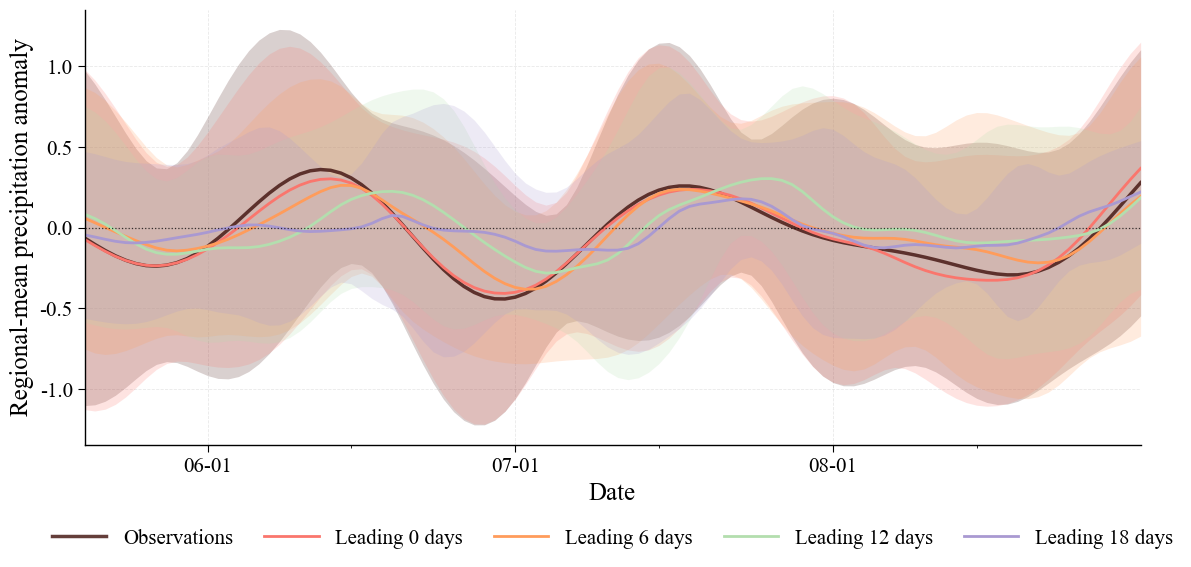

In [45]:
import os
import glob
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import t
from tqdm import tqdm


# 1. 参数设置

PRED_ROOT = r"C:/Users/sysu/Desktop/tp_reconstruction/results/miso_dilated_se"
TARGET_DIR = r"C:/Users/sysu/Desktop/tp_reconstruction/data/test/tp"

LEAD_TIMES = [0, 6, 12, 18]

# None：自动识别共同数据中的年份，并要求正好有6年
# 也可以手动指定，例如：
# YEARS = [2018, 2019, 2020, 2021, 2022, 2023]
YEARS = None

# 横坐标固定显示区间
START_MMDD = "0520"
END_MMDD = "0831"

TP_MIN = -30.7176074981689
TP_MAX = 28.9318389892578

# Observation + 4个leading time
# COLORS = {
#     "Observations": "#E79C96",
#     "Leading 0 days": "#F2C17E",
#     "Leading 6 days": "#F0E8D8",
#     "Leading 12 days": "#DAEDD8",
#     "Leading 18 days": "#D9D3E8",
# }
COLORS = {
    "Observations": "#431410D2",
    "Leading 0 days": "#FA766D",
    "Leading 6 days": "#FF9C5B",
    "Leading 12 days": "#B3DEAE",
    "Leading 18 days": "#A999D1",
}

LINE_WIDTH = {
    "Observations": 2.5,
    "Leading 0 days": 2.0,
    "Leading 6 days": 2.0,
    "Leading 12 days": 2.0,
    "Leading 18 days": 2.0,
}

CI_ALPHA = 0.2

# 数据中的0是否代表无效值
EXCLUDE_ZERO = False

# 是否要求每个月日都有完整6年的数据
REQUIRE_ALL_YEARS = True


# 2. Times New Roman绘图设置

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "axes.linewidth": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.unicode_minus": False,
})


# 3. 工具函数

def denormalize(tp):
    """将[-1, 1]恢复到原始TP异常尺度。"""
    return ((tp + 1.0) / 2.0) * (TP_MAX - TP_MIN) + TP_MIN


def get_date_from_path(file_path):
    """从YYYYMMDD.npy文件名中提取日期。"""
    date_string = os.path.splitext(os.path.basename(file_path))[0]
    datetime.strptime(date_string, "%Y%m%d")
    return date_string


def get_file_dict(folder):
    """获取文件夹中所有合法的YYYYMMDD.npy文件。"""
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Folder does not exist: {folder}")

    file_dict = {}

    for file_path in glob.glob(os.path.join(folder, "*.npy")):
        try:
            date_string = get_date_from_path(file_path)
        except ValueError:
            continue

        file_dict[date_string] = file_path

    return dict(sorted(file_dict.items()))


def load_field(file_path):
    """读取二维场并反归一化。"""
    field = np.load(file_path, allow_pickle=False)
    field = np.squeeze(field).astype(np.float64)

    if field.ndim != 2:
        raise ValueError(
            f"Expected a 2D array, but got {field.shape}: {file_path}"
        )

    field = denormalize(field)

    if not np.isfinite(field).all():
        raise ValueError(f"NaN or Inf found in: {file_path}")

    return field


def calculate_regional_mean(field):
    """计算一个日期二维场的区域平均。"""
    valid_mask = np.isfinite(field)

    if EXCLUDE_ZERO:
        valid_mask &= field != 0

    valid_values = field[valid_mask]

    if valid_values.size == 0:
        return np.nan

    return float(np.mean(valid_values))


def generate_mmdd_sequence(start_mmdd, end_mmdd):
    """
    使用虚拟年份2000构建固定月日序列，
    便于把不同年份对齐到同一横坐标。
    """
    start_date = datetime.strptime(f"2000{start_mmdd}", "%Y%m%d")
    end_date = datetime.strptime(f"2000{end_mmdd}", "%Y%m%d")

    date_range = np.arange(
        np.datetime64(start_date.date()),
        np.datetime64(end_date.date()) + np.timedelta64(1, "D"),
        np.timedelta64(1, "D"),
    )

    reference_dates = [
        datetime.strptime(str(date_value), "%Y-%m-%d")
        for date_value in date_range
    ]

    mmdd_sequence = [
        date_value.strftime("%m%d")
        for date_value in reference_dates
    ]

    return reference_dates, mmdd_sequence


def calculate_six_year_mean_ci(year_matrix):
    """
    对形状[6, number_of_days]的数据逐日计算：
        6年平均
        95%置信区间

    95% CI = t_(0.975,n-1) × SEM
    """
    number_of_days = year_matrix.shape[1]

    mean_values = np.full(number_of_days, np.nan, dtype=np.float64)
    ci_half_width = np.full(number_of_days, np.nan, dtype=np.float64)

    for day_index in range(number_of_days):
        values = year_matrix[:, day_index]
        values = values[np.isfinite(values)]
        sample_count = values.size

        if REQUIRE_ALL_YEARS and sample_count != 6:
            continue

        if sample_count == 0:
            continue

        mean_values[day_index] = np.mean(values)

        if sample_count == 1:
            ci_half_width[day_index] = 0.0
            continue

        standard_error = np.std(values, ddof=1) / np.sqrt(sample_count)
        critical_value = t.ppf(0.975, df=sample_count - 1)
        ci_half_width[day_index] = critical_value * standard_error

    return mean_values, ci_half_width


# 4. 读取target与预测文件索引

target_files = get_file_dict(TARGET_DIR)

prediction_files = {}

for lead_time in LEAD_TIMES:
    lead_folder = os.path.join(PRED_ROOT, f"leading{lead_time}")
    prediction_files[lead_time] = get_file_dict(lead_folder)

# target和所有leading time共同存在的日期
common_dates = set(target_files.keys())

for lead_time in LEAD_TIMES:
    common_dates &= set(prediction_files[lead_time].keys())

common_dates = sorted(common_dates)

if not common_dates:
    raise RuntimeError(
        "No common dates exist among target and all prediction folders."
    )


# 5. 确定6个年份

available_years = sorted({
    int(date_string[:4])
    for date_string in common_dates
    if START_MMDD <= date_string[4:] <= END_MMDD
})

if YEARS is None:
    selected_years = available_years
else:
    selected_years = list(YEARS)

if len(selected_years) != 6:
    raise ValueError(
        "Exactly six years are required./n"
        f"Selected years: {selected_years}/n"
        f"Available years: {available_years}"
    )

missing_years = [
    year for year in selected_years
    if year not in available_years
]

if missing_years:
    raise ValueError(
        f"These selected years are unavailable: {missing_years}"
    )

print(f"Six years used: {selected_years}")


# 6. 构建固定的月日横坐标

reference_dates, mmdd_sequence = generate_mmdd_sequence(
    START_MMDD,
    END_MMDD,
)

number_of_days = len(mmdd_sequence)

series_names = [
    "Observations",
    "Leading 0 days",
    "Leading 6 days",
    "Leading 12 days",
    "Leading 18 days",
]

# 每个变量保存为[6年, 日期数]
yearly_series = {
    series_name: np.full(
        (len(selected_years), number_of_days),
        np.nan,
        dtype=np.float64,
    )
    for series_name in series_names
}


# 7. 逐年、逐日计算区域平均

for year_index, year in enumerate(selected_years):
    progress_bar = tqdm(
        enumerate(mmdd_sequence),
        total=number_of_days,
        desc=f"Processing {year}",
        dynamic_ncols=True,
    )

    for day_index, mmdd in progress_bar:
        date_string = f"{year}{mmdd}"

        if date_string not in common_dates:
            continue

        # Observation就是当天TP target
        target_field = load_field(target_files[date_string])

        yearly_series["Observations"][
            year_index,
            day_index,
        ] = calculate_regional_mean(target_field)

        # 各leading time预测
        for lead_time in LEAD_TIMES:
            prediction_field = load_field(
                prediction_files[lead_time][date_string]
            )

            yearly_series[f"Leading {lead_time} days"][
                year_index,
                day_index,
            ] = calculate_regional_mean(prediction_field)


# 8. 计算6年平均和95%置信区间

mean_series = {}
ci_series = {}

for series_name in series_names:
    mean_values, ci_values = calculate_six_year_mean_ci(
        yearly_series[series_name]
    )

    mean_series[series_name] = mean_values
    ci_series[series_name] = ci_values

    valid_day_count = np.sum(np.isfinite(mean_values))

    print(
        f"{series_name}: "
        f"{valid_day_count}/{number_of_days} valid calendar days"
    )


# 9. 绘制单幅6年平均图

fig, ax = plt.subplots(figsize=(12, 5.8))

for series_name in series_names:
    mean_values = mean_series[series_name]
    ci_values = ci_series[series_name]

    lower_bound = mean_values - ci_values
    upper_bound = mean_values + ci_values

    ax.fill_between(
        reference_dates,
        lower_bound,
        upper_bound,
        color=COLORS[series_name],
        alpha=CI_ALPHA,
        linewidth=0,
        zorder=1,
    )

    ax.plot(
        reference_dates,
        mean_values,
        color=COLORS[series_name],
        linewidth=LINE_WIDTH[series_name],
        label=series_name,
        zorder=2,
    )

# 零异常参考线
ax.axhline(
    y=0,
    color="black",
    linestyle=":",
    linewidth=0.9,
    alpha=0.75,
    zorder=3,
)

ax.set_xlabel("Date")
ax.set_ylabel("Regional-mean precipitation anomaly")

# 固定横轴区间
axis_start = datetime.strptime(f"2000{START_MMDD}", "%Y%m%d")
axis_end = datetime.strptime(f"2000{END_MMDD}", "%Y%m%d")

ax.set_xlim(axis_start, axis_end)

# 每月1日显示一个主刻度
ax.xaxis.set_major_locator(
    mdates.MonthLocator(bymonthday=1)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%m-%d")
)

# 可选的每半月次刻度
ax.xaxis.set_minor_locator(
    mdates.DayLocator(bymonthday=[15])
)

ax.grid(
    axis="both",
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.28,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=15,
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=5,
    frameon=False,
    handlelength=2.6,
    columnspacing=1.5,
)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    top=0.97,
    bottom=0.22,
)
fig.savefig("C:/Users/sysu/Desktop/tp_reconstruction/results/figures/tp_index.png", dpi=600, bbox_inches="tight",)
plt.show()

Six years used: [2014, 2015, 2016, 2017, 2018, 2019]


Processing 2019: 100%|██████████| 104/104 [00:00<00:00, 1964.81it/s]


Observations: 104/104 valid calendar days
Leading 0 days: 104/104 valid calendar days
Leading 6 days: 104/104 valid calendar days
Leading 12 days: 104/104 valid calendar days
Leading 18 days: 104/104 valid calendar days


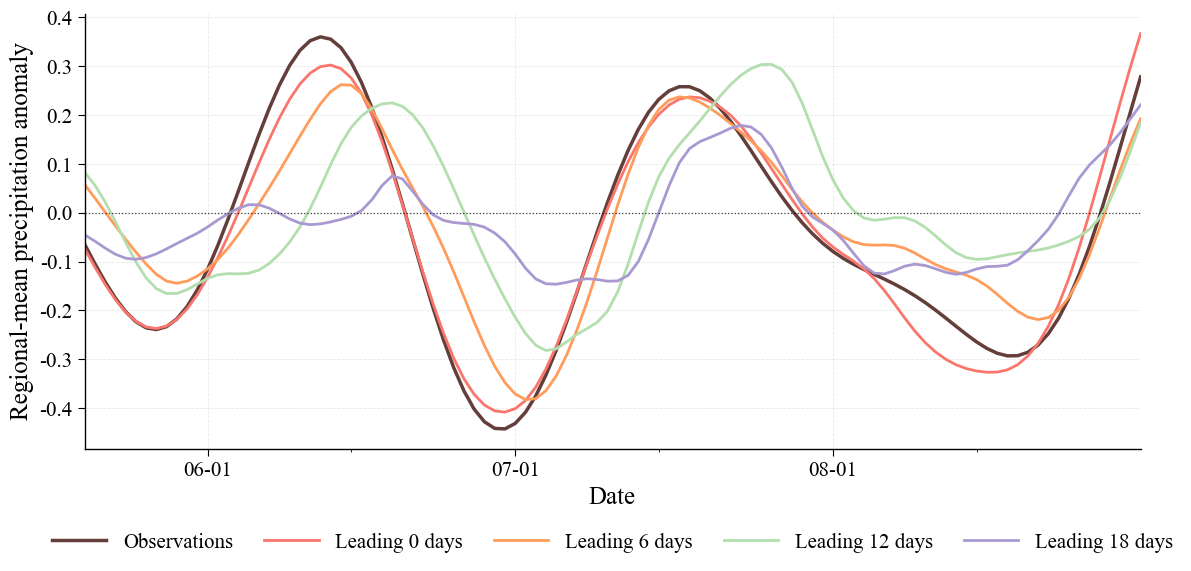

In [47]:
import os
import glob
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import t
from tqdm import tqdm


# 1. 参数设置

PRED_ROOT = r"C:/Users/sysu/Desktop/tp_reconstruction/results/miso_dilated_se"
TARGET_DIR = r"C:/Users/sysu/Desktop/tp_reconstruction/data/test/tp"

LEAD_TIMES = [0, 6, 12, 18]

# None：自动识别共同数据中的年份，并要求正好有6年
# 也可以手动指定，例如：
# YEARS = [2018, 2019, 2020, 2021, 2022, 2023]
YEARS = None

# 横坐标固定显示区间
START_MMDD = "0520"
END_MMDD = "0831"

TP_MIN = -30.7176074981689
TP_MAX = 28.9318389892578

# Observation + 4个leading time
# COLORS = {
#     "Observations": "#E79C96",
#     "Leading 0 days": "#F2C17E",
#     "Leading 6 days": "#F0E8D8",
#     "Leading 12 days": "#DAEDD8",
#     "Leading 18 days": "#D9D3E8",
# }
COLORS = {
    "Observations": "#431410D2",
    "Leading 0 days": "#FA766D",
    "Leading 6 days": "#FF9C5B",
    "Leading 12 days": "#B3DEAE",
    "Leading 18 days": "#A999D1",
}

LINE_WIDTH = {
    "Observations": 2.5,
    "Leading 0 days": 2.0,
    "Leading 6 days": 2.0,
    "Leading 12 days": 2.0,
    "Leading 18 days": 2.0,
}

CI_ALPHA = 0.2

# 数据中的0是否代表无效值
EXCLUDE_ZERO = False

# 是否要求每个月日都有完整6年的数据
REQUIRE_ALL_YEARS = True


# 2. Times New Roman绘图设置

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "axes.linewidth": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.unicode_minus": False,
})


# 3. 工具函数

def denormalize(tp):
    """将[-1, 1]恢复到原始TP异常尺度。"""
    return ((tp + 1.0) / 2.0) * (TP_MAX - TP_MIN) + TP_MIN


def get_date_from_path(file_path):
    """从YYYYMMDD.npy文件名中提取日期。"""
    date_string = os.path.splitext(os.path.basename(file_path))[0]
    datetime.strptime(date_string, "%Y%m%d")
    return date_string


def get_file_dict(folder):
    """获取文件夹中所有合法的YYYYMMDD.npy文件。"""
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Folder does not exist: {folder}")

    file_dict = {}

    for file_path in glob.glob(os.path.join(folder, "*.npy")):
        try:
            date_string = get_date_from_path(file_path)
        except ValueError:
            continue

        file_dict[date_string] = file_path

    return dict(sorted(file_dict.items()))


def load_field(file_path):
    """读取二维场并反归一化。"""
    field = np.load(file_path, allow_pickle=False)
    field = np.squeeze(field).astype(np.float64)

    if field.ndim != 2:
        raise ValueError(
            f"Expected a 2D array, but got {field.shape}: {file_path}"
        )

    field = denormalize(field)

    if not np.isfinite(field).all():
        raise ValueError(f"NaN or Inf found in: {file_path}")

    return field


def calculate_regional_mean(field):
    """计算一个日期二维场的区域平均。"""
    valid_mask = np.isfinite(field)

    if EXCLUDE_ZERO:
        valid_mask &= field != 0

    valid_values = field[valid_mask]

    if valid_values.size == 0:
        return np.nan

    return float(np.mean(valid_values))


def generate_mmdd_sequence(start_mmdd, end_mmdd):
    """
    使用虚拟年份2000构建固定月日序列，
    便于把不同年份对齐到同一横坐标。
    """
    start_date = datetime.strptime(f"2000{start_mmdd}", "%Y%m%d")
    end_date = datetime.strptime(f"2000{end_mmdd}", "%Y%m%d")

    date_range = np.arange(
        np.datetime64(start_date.date()),
        np.datetime64(end_date.date()) + np.timedelta64(1, "D"),
        np.timedelta64(1, "D"),
    )

    reference_dates = [
        datetime.strptime(str(date_value), "%Y-%m-%d")
        for date_value in date_range
    ]

    mmdd_sequence = [
        date_value.strftime("%m%d")
        for date_value in reference_dates
    ]

    return reference_dates, mmdd_sequence


def calculate_six_year_mean_ci(year_matrix):
    """
    对形状[6, number_of_days]的数据逐日计算：
        6年平均
        95%置信区间

    95% CI = t_(0.975,n-1) × SEM
    """
    number_of_days = year_matrix.shape[1]

    mean_values = np.full(number_of_days, np.nan, dtype=np.float64)
    ci_half_width = np.full(number_of_days, np.nan, dtype=np.float64)

    for day_index in range(number_of_days):
        values = year_matrix[:, day_index]
        values = values[np.isfinite(values)]
        sample_count = values.size

        if REQUIRE_ALL_YEARS and sample_count != 6:
            continue

        if sample_count == 0:
            continue

        mean_values[day_index] = np.mean(values)

        if sample_count == 1:
            ci_half_width[day_index] = 0.0
            continue

        standard_error = np.std(values, ddof=1) / np.sqrt(sample_count)
        critical_value = t.ppf(0.975, df=sample_count - 1)
        ci_half_width[day_index] = critical_value * standard_error

    return mean_values, ci_half_width


# 4. 读取target与预测文件索引

target_files = get_file_dict(TARGET_DIR)

prediction_files = {}

for lead_time in LEAD_TIMES:
    lead_folder = os.path.join(PRED_ROOT, f"leading{lead_time}")
    prediction_files[lead_time] = get_file_dict(lead_folder)

# target和所有leading time共同存在的日期
common_dates = set(target_files.keys())

for lead_time in LEAD_TIMES:
    common_dates &= set(prediction_files[lead_time].keys())

common_dates = sorted(common_dates)

if not common_dates:
    raise RuntimeError(
        "No common dates exist among target and all prediction folders."
    )


# 5. 确定6个年份

available_years = sorted({
    int(date_string[:4])
    for date_string in common_dates
    if START_MMDD <= date_string[4:] <= END_MMDD
})

if YEARS is None:
    selected_years = available_years
else:
    selected_years = list(YEARS)

if len(selected_years) != 6:
    raise ValueError(
        "Exactly six years are required./n"
        f"Selected years: {selected_years}/n"
        f"Available years: {available_years}"
    )

missing_years = [
    year for year in selected_years
    if year not in available_years
]

if missing_years:
    raise ValueError(
        f"These selected years are unavailable: {missing_years}"
    )

print(f"Six years used: {selected_years}")


# 6. 构建固定的月日横坐标

reference_dates, mmdd_sequence = generate_mmdd_sequence(
    START_MMDD,
    END_MMDD,
)

number_of_days = len(mmdd_sequence)

series_names = [
    "Observations",
    "Leading 0 days",
    "Leading 6 days",
    "Leading 12 days",
    "Leading 18 days",
]

# 每个变量保存为[6年, 日期数]
yearly_series = {
    series_name: np.full(
        (len(selected_years), number_of_days),
        np.nan,
        dtype=np.float64,
    )
    for series_name in series_names
}


# 7. 逐年、逐日计算区域平均

for year_index, year in enumerate(selected_years):
    progress_bar = tqdm(
        enumerate(mmdd_sequence),
        total=number_of_days,
        desc=f"Processing {year}",
        dynamic_ncols=True,
    )

    for day_index, mmdd in progress_bar:
        date_string = f"{year}{mmdd}"

        if date_string not in common_dates:
            continue

        # Observation就是当天TP target
        target_field = load_field(target_files[date_string])

        yearly_series["Observations"][
            year_index,
            day_index,
        ] = calculate_regional_mean(target_field)

        # 各leading time预测
        for lead_time in LEAD_TIMES:
            prediction_field = load_field(
                prediction_files[lead_time][date_string]
            )

            yearly_series[f"Leading {lead_time} days"][
                year_index,
                day_index,
            ] = calculate_regional_mean(prediction_field)


# 8. 计算6年平均和95%置信区间

mean_series = {}
ci_series = {}

for series_name in series_names:
    mean_values, ci_values = calculate_six_year_mean_ci(
        yearly_series[series_name]
    )

    mean_series[series_name] = mean_values
    ci_series[series_name] = ci_values

    valid_day_count = np.sum(np.isfinite(mean_values))

    print(
        f"{series_name}: "
        f"{valid_day_count}/{number_of_days} valid calendar days"
    )


# 9. 绘制单幅6年平均图

fig, ax = plt.subplots(figsize=(12, 5.8))

for series_name in series_names:
    mean_values = mean_series[series_name]
    ci_values = ci_series[series_name]

    lower_bound = mean_values - ci_values
    upper_bound = mean_values + ci_values

    # ax.fill_between(
    #     reference_dates,
    #     lower_bound,
    #     upper_bound,
    #     color=COLORS[series_name],
    #     alpha=CI_ALPHA,
    #     linewidth=0,
    #     zorder=1,
    # )

    ax.plot(
        reference_dates,
        mean_values,
        color=COLORS[series_name],
        linewidth=LINE_WIDTH[series_name],
        label=series_name,
        zorder=2,
    )

# 零异常参考线
ax.axhline(
    y=0,
    color="black",
    linestyle=":",
    linewidth=0.9,
    alpha=0.75,
    zorder=3,
)

ax.set_xlabel("Date")
ax.set_ylabel("Regional-mean precipitation anomaly")

# 固定横轴区间
axis_start = datetime.strptime(f"2000{START_MMDD}", "%Y%m%d")
axis_end = datetime.strptime(f"2000{END_MMDD}", "%Y%m%d")

ax.set_xlim(axis_start, axis_end)

# 每月1日显示一个主刻度
ax.xaxis.set_major_locator(
    mdates.MonthLocator(bymonthday=1)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%m-%d")
)

# 可选的每半月次刻度
ax.xaxis.set_minor_locator(
    mdates.DayLocator(bymonthday=[15])
)

ax.grid(
    axis="both",
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.28,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=15,
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=5,
    frameon=False,
    handlelength=2.6,
    columnspacing=1.5,
)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    top=0.97,
    bottom=0.22,
)
fig.savefig("C:/Users/sysu/Desktop/tp_reconstruction/results/figures/tp_index.png", dpi=600, bbox_inches="tight",)
plt.show()

shap可解释性分析图

SHAP root: C:\Users\sysu\Desktop\tp_reconstruction\gradient_shap
SST directory: C:\Users\sysu\Desktop\tp_reconstruction\data\test\sst
Output directory: C:\Users\sysu\Desktop\tp_reconstruction\results\gradient_shap_result_plot
Lead times: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
Use common dates: True
SST channel index: 9
Leading  0 days: 738 files
Leading  2 days: 726 files
Leading  4 days: 714 files
Leading  6 days: 702 files
Leading  8 days: 690 files
Leading 10 days: 678 files
Leading 12 days: 666 files
Leading 14 days: 654 files
Leading 16 days: 642 files
Leading 18 days: 630 files
Leading 20 days: 618 files

Use common target dates across all leading folders: 618 samples



Leading  0: 100%|██████████| 618/618 [00:00<00:00, 1171.07it/s, input=20190831, sst_valid=323, target=20190831]


Leading  0: samples=618, contribution sum=100.000000%, mean SST valid pixels=323.00


Leading  2: 100%|██████████| 618/618 [00:00<00:00, 1155.93it/s, input=20190829, sst_valid=323, target=20190831]


Leading  2: samples=618, contribution sum=100.000000%, mean SST valid pixels=323.00


...

Leading 16: samples=618, contribution sum=100.000000%, mean SST valid pixels=323.00


Leading 18: 100%|██████████| 618/618 [00:00<00:00, 1193.60it/s, input=20190813, sst_valid=323, target=20190831]


Leading 18: samples=618, contribution sum=100.000000%, mean SST valid pixels=323.00


Leading 20: 100%|██████████| 618/618 [00:00<00:00, 1217.67it/s, input=20190811, sst_valid=323, target=20190831]


Leading 20: samples=618, contribution sum=100.000000%, mean SST valid pixels=323.00

Statistics saved:
C:\Users\sysu\Desktop\tp_reconstruction\results\gradient_shap_result_plot\mean_relative_shap_contribution.csv
C:\Users\sysu\Desktop\tp_reconstruction\results\gradient_shap_result_plot\std_relative_shap_contribution.csv
C:\Users\sysu\Desktop\tp_reconstruction\results\gradient_shap_result_plot\sample_counts.csv
C:\Users\sysu\Desktop\tp_reconstruction\results\gradient_shap_result_plot\daily_contributions


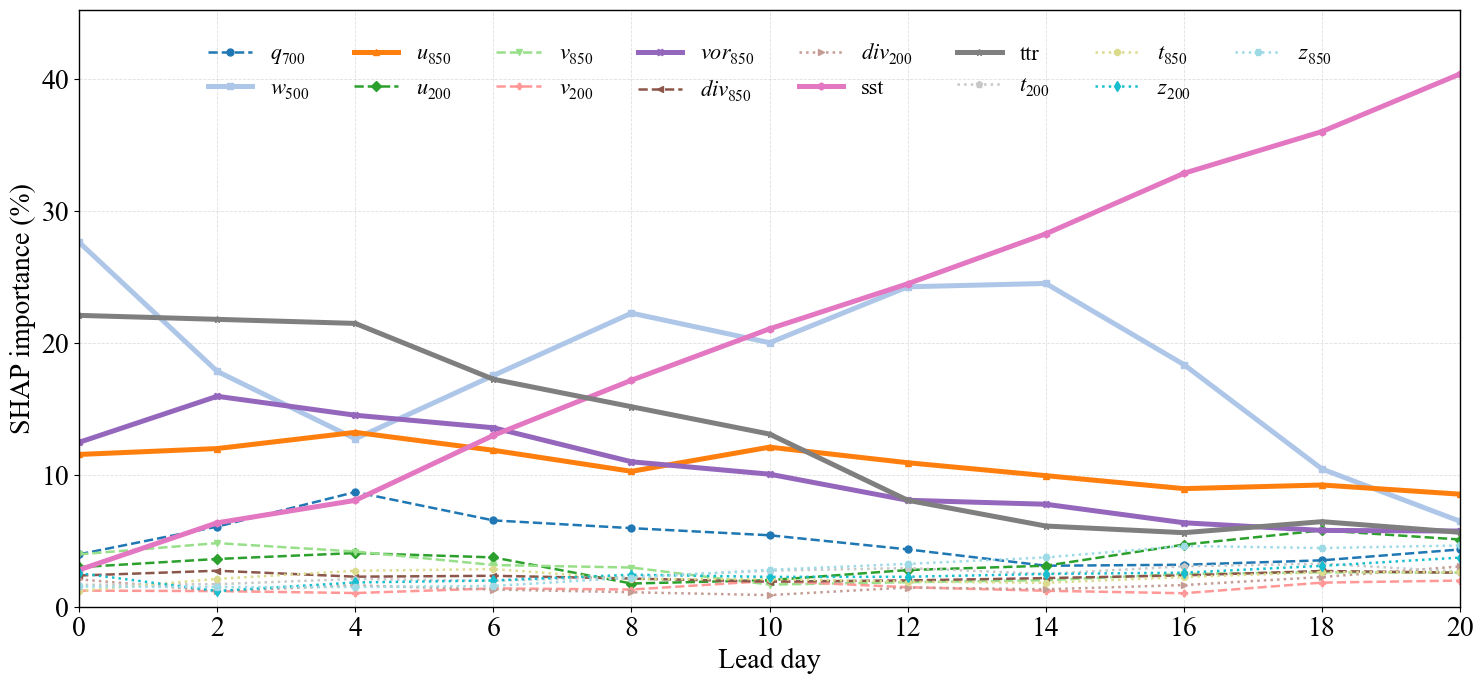


Figures saved:
C:\Users\sysu\Desktop\tp_reconstruction\results\gradient_shap_result_plot\relative_shap_contribution_by_lead_time.png
C:\Users\sysu\Desktop\tp_reconstruction\results\gradient_shap_result_plot\relative_shap_contribution_by_lead_time.pdf

Final mean relative contributions (%):
          q_700   w_500   u_850  u_200  v_850  v_200  vor_850  div_850  \
lead_day                                                                 
0         3.970  27.616  11.537  2.996  3.968  1.220   12.455    2.364   
2         6.070  17.832  11.984  3.618  4.819  1.183   15.945    2.726   
4         8.691  12.722  13.213  4.067  4.183  1.036   14.509    2.276   
6         6.541  17.520  11.853  3.738  3.160  1.388   13.560    2.343   
8         5.953  22.244  10.258  1.758  2.968  1.303   10.982    2.134   
10        5.413  20.003  12.091  2.011  1.678  1.961   10.042    1.902   
12        4.346  24.238  10.910  2.780  1.860  1.478    8.066    1.993   
14        3.105  24.495   9.930  3.105  2.

In [39]:
import os
import re
import glob
from datetime import datetime, timedelta
from scipy.stats import gaussian_kde

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


# ============================================================
# 1. 参数设置
# ============================================================

# SHAP结果根目录
# 目录下应包含：
# leading0、leading2、leading4、...、leading20
ROOT_DIR = r"C:\Users\sysu\Desktop\tp_reconstruction\gradient_shap"

# 原始验证集SST文件夹
# 文件格式为：YYYYMMDD.npy
SST_DIR = r"C:\Users\sysu\Desktop\tp_reconstruction\data\test\sst"

# 统计结果和图片保存目录
OUTPUT_DIR = r"C:\Users\sysu\Desktop\tp_reconstruction\results\gradient_shap_result_plot"

# 提前时间
LEAD_TIMES = list(range(0, 21, 2))

# 文件夹命名方式
LEADING_FOLDER_FORMAT = "leading{}"

# SHAP文件中的15个输入通道顺序
NAME_LIST = [
    "q_700",
    "w_500",
    "u_850",
    "u_200",
    "v_850",
    "v_200",
    "vor_850",
    "div_850",
    "div_200",
    "sst",
    "ttr",
    "t_200",
    "t_850",
    "z_200",
    "z_850",
]

def to_latex_subscript(name):
    if '_' in name:
        prefix, num = name.split('_')
        return f"${prefix}_{{{num}}}$"  # 如 q_{700}
    return name

# SST所在的通道索引
SST_CHANNEL_INDEX = NAME_LIST.index("sst")

# SHAP数组尺寸
EXPECTED_HEIGHT = 31
EXPECTED_WIDTH = 21

# SST陆地值为0
# 若担心存在很小的浮点误差，可以改成1e-8
SST_ZERO_EPS = 0.0

# 是否只使用所有leading文件夹中共同存在的日期
# True更适合比较不同lead time
USE_COMMON_DATES = True

# 是否在折线图上显示点
SHOW_MARKERS = True

# 图片分辨率
FIG_DPI = 300


# ============================================================
# 2. 绘图字体设置
# ============================================================

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12
plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 3. 日期与文件读取
# ============================================================

def get_shap_files(folder_path):
    """
    获取一个leading文件夹中的所有YYYYMMDD.npy文件。

    Returns
    -------
    dict
        {
            "20190601": "完整文件路径",
            ...
        }
    """
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(
            f"SHAP folder does not exist: {folder_path}"
        )

    filename_pattern = re.compile(r"^\d{8}\.npy$")

    file_dict = {}

    for file_path in glob.glob(
        os.path.join(folder_path, "*.npy")
    ):
        file_name = os.path.basename(file_path)

        if not filename_pattern.match(file_name):
            continue

        date_name = os.path.splitext(file_name)[0]
        file_dict[date_name] = file_path

    return dict(sorted(file_dict.items()))


def get_all_leading_files():
    """
    读取所有leading文件夹中的SHAP文件索引。
    """
    all_files = {}

    for lead_time in LEAD_TIMES:
        folder_name = LEADING_FOLDER_FORMAT.format(
            lead_time
        )

        folder_path = os.path.join(
            ROOT_DIR,
            folder_name,
        )

        file_dict = get_shap_files(folder_path)

        if len(file_dict) == 0:
            raise RuntimeError(
                f"No valid SHAP files found in: {folder_path}"
            )

        all_files[lead_time] = file_dict

        print(
            f"Leading {lead_time:>2} days: "
            f"{len(file_dict)} files"
        )

    return all_files


def target_date_to_input_date(
    target_date,
    lead_time,
):
    """
    根据SHAP文件对应的target日期，计算模型输入日期。

    input_date = target_date - lead_time

    例如：
        target_date = 20190609
        lead_time = 8
        input_date = 20190601
    """
    target_datetime = datetime.strptime(
        target_date,
        "%Y%m%d",
    )

    input_datetime = target_datetime - timedelta(
        days=int(lead_time)
    )

    return input_datetime.strftime("%Y%m%d")


def load_input_sst(
    target_date,
    lead_time,
):
    """
    读取当前SHAP样本实际使用的输入日期SST。

    SHAP文件按target_date命名，因此：
        input_date = target_date - lead_time
    """
    input_date = target_date_to_input_date(
        target_date=target_date,
        lead_time=lead_time,
    )

    sst_path = os.path.join(
        SST_DIR,
        f"{input_date}.npy",
    )

    if not os.path.isfile(sst_path):
        raise FileNotFoundError(
            "Corresponding SST file does not exist.\n"
            f"Target date: {target_date}\n"
            f"Lead time: {lead_time}\n"
            f"Input date: {input_date}\n"
            f"SST path: {sst_path}"
        )

    sst_array = np.load(
        sst_path,
        allow_pickle=False,
    )

    sst_array = np.squeeze(sst_array)

    expected_shape = (
        EXPECTED_HEIGHT,
        EXPECTED_WIDTH,
    )

    if sst_array.shape != expected_shape:
        raise ValueError(
            f"Invalid SST shape: {sst_path}\n"
            f"Expected: {expected_shape}\n"
            f"Received: {sst_array.shape}"
        )

    if not np.isfinite(sst_array).all():
        raise ValueError(
            f"NaN or Inf found in SST file: {sst_path}"
        )

    return sst_array, input_date, sst_path


# ============================================================
# 4. 单日SHAP贡献计算
# ============================================================

def calculate_sample_contribution(
    shap_array,
    shap_file_path,
    target_date,
    lead_time,
):
    """
    计算某一天15个变量的相对SHAP贡献。

    普通变量：
        在完整31×21区域计算平均绝对SHAP。

    SST变量：
        根据target_date和lead_time读取对应输入日期SST，
        仅在SST不等于0的有效海洋格点计算平均绝对SHAP。

    最后：
        在当天15个变量之间归一化为百分比。

    Returns
    -------
    relative_contribution : np.ndarray
        Shape为[15]，15个变量之和为100%。

    channel_importance : np.ndarray
        归一化前的15个通道平均绝对SHAP。

    valid_sst_pixels : int
        SST有效海洋格点数量。

    input_date : str
        当前样本对应的输入日期。
    """
    shap_array = np.asarray(
        shap_array,
        dtype=np.float64,
    )

    # 兼容可能额外存在的大小为1的维度
    shap_array = np.squeeze(shap_array)

    expected_shape = (
        len(NAME_LIST),
        EXPECTED_HEIGHT,
        EXPECTED_WIDTH,
    )

    if shap_array.shape != expected_shape:
        raise ValueError(
            f"Invalid SHAP shape: {shap_file_path}\n"
            f"Expected: {expected_shape}\n"
            f"Received: {shap_array.shape}"
        )

    if not np.isfinite(shap_array).all():
        raise ValueError(
            f"NaN or Inf found in SHAP file: "
            f"{shap_file_path}"
        )

    # 使用绝对SHAP表示贡献强度
    absolute_shap = np.abs(shap_array)

    # 普通变量默认在完整31×21区域取平均
    # [15,31,21] -> [15]
    channel_importance = np.mean(
        absolute_shap,
        axis=(1, 2),
    )

    # 读取对应输入日期的SST
    sst_array, input_date, sst_path = load_input_sst(
        target_date=target_date,
        lead_time=lead_time,
    )

    # 构建SST有效海洋格点掩膜
    if SST_ZERO_EPS == 0:
        valid_sst_mask = sst_array != 0
    else:
        valid_sst_mask = (
            np.abs(sst_array) > SST_ZERO_EPS
        )

    valid_sst_pixels = int(
        np.sum(valid_sst_mask)
    )

    if valid_sst_pixels == 0:
        raise ValueError(
            "No valid SST pixels found.\n"
            f"Input date: {input_date}\n"
            f"Target date: {target_date}\n"
            f"SST file: {sst_path}"
        )

    # SST通道只在有效海洋格点上取平均
    sst_shap_map = absolute_shap[
        SST_CHANNEL_INDEX
    ]

    sst_importance = np.mean(
        sst_shap_map[valid_sst_mask]
    )

    channel_importance[
        SST_CHANNEL_INDEX
    ] = sst_importance

    total_importance = np.sum(
        channel_importance
    )

    if not np.isfinite(total_importance):
        raise ValueError(
            f"Invalid total SHAP importance: "
            f"{shap_file_path}"
        )

    if total_importance <= 0:
        raise ValueError(
            f"Total absolute SHAP importance is zero: "
            f"{shap_file_path}"
        )

    # 每一天在15个变量之间归一化
    relative_contribution = (
        channel_importance
        / total_importance
        * 100.0
    )

    return (
        relative_contribution,
        channel_importance,
        valid_sst_pixels,
        input_date,
    )


# ============================================================
# 5. 统计所有leading time
# ============================================================

def calculate_all_contributions(all_files):
    """
    计算所有leading time下15个变量的平均相对贡献。

    计算顺序：
    1. 每天计算每个变量的平均绝对SHAP；
    2. 每天在15个变量间归一化为100%；
    3. 对所有日期的百分比贡献取平均。

    Returns
    -------
    mean_contributions : np.ndarray
        Shape为[len(LEAD_TIMES), 15]。

    std_contributions : np.ndarray
        每个lead time下每日相对贡献的标准差。

    sample_counts : list
        每个lead time使用的样本数量。

    daily_results : dict
        保存每个lead time下的逐日贡献。
    """
    if USE_COMMON_DATES:
        date_sets = [
            set(file_dict.keys())
            for file_dict in all_files.values()
        ]

        common_dates = sorted(
            set.intersection(*date_sets)
        )

        if len(common_dates) == 0:
            raise RuntimeError(
                "No common dates exist across all "
                "leading folders."
            )

        print(
            "\nUse common target dates across all "
            f"leading folders: {len(common_dates)} samples\n"
        )

    else:
        common_dates = None

        print(
            "\nEach leading folder uses all of its "
            "own samples.\n"
        )

    mean_contributions = []
    std_contributions = []
    sample_counts = []

    daily_results = {}

    for lead_time in LEAD_TIMES:
        file_dict = all_files[lead_time]

        if USE_COMMON_DATES:
            current_dates = common_dates
        else:
            current_dates = sorted(
                file_dict.keys()
            )

        daily_contributions = []
        daily_absolute_importance = []
        daily_input_dates = []
        daily_sst_valid_pixels = []

        progress_bar = tqdm(
            current_dates,
            desc=f"Leading {lead_time:>2}",
            dynamic_ncols=True,
        )

        for target_date in progress_bar:
            shap_file_path = file_dict[
                target_date
            ]

            shap_array = np.load(
                shap_file_path,
                allow_pickle=False,
            )

            (
                relative_contribution,
                channel_importance,
                valid_sst_pixels,
                input_date,
            ) = calculate_sample_contribution(
                shap_array=shap_array,
                shap_file_path=shap_file_path,
                target_date=target_date,
                lead_time=lead_time,
            )

            daily_contributions.append(
                relative_contribution
            )

            daily_absolute_importance.append(
                channel_importance
            )

            daily_input_dates.append(
                input_date
            )

            daily_sst_valid_pixels.append(
                valid_sst_pixels
            )

            progress_bar.set_postfix(
                target=target_date,
                input=input_date,
                sst_valid=valid_sst_pixels,
            )

        # [N,15]
        daily_contributions = np.stack(
            daily_contributions,
            axis=0,
        )

        daily_absolute_importance = np.stack(
            daily_absolute_importance,
            axis=0,
        )

        # 对逐日归一化后的贡献百分比取平均
        mean_contribution = np.mean(
            daily_contributions,
            axis=0,
        )

        std_contribution = np.std(
            daily_contributions,
            axis=0,
            ddof=0,
        )

        contribution_sum = np.sum(
            mean_contribution
        )

        print(
            f"Leading {lead_time:>2}: "
            f"samples={len(current_dates)}, "
            f"contribution sum={contribution_sum:.6f}%, "
            f"mean SST valid pixels="
            f"{np.mean(daily_sst_valid_pixels):.2f}"
        )

        mean_contributions.append(
            mean_contribution
        )

        std_contributions.append(
            std_contribution
        )

        sample_counts.append(
            len(current_dates)
        )

        daily_results[lead_time] = {
            "target_dates": current_dates,
            "input_dates": daily_input_dates,
            "relative_contributions": (
                daily_contributions
            ),
            "absolute_importance": (
                daily_absolute_importance
            ),
            "sst_valid_pixels": np.asarray(
                daily_sst_valid_pixels
            ),
        }

    mean_contributions = np.stack(
        mean_contributions,
        axis=0,
    )

    std_contributions = np.stack(
        std_contributions,
        axis=0,
    )

    return (
        mean_contributions,
        std_contributions,
        sample_counts,
        daily_results,
    )


# ============================================================
# 6. 保存统计结果
# ============================================================

def save_statistics(
    mean_contributions,
    std_contributions,
    sample_counts,
    daily_results,
):
    """
    保存平均贡献、标准差、样本数以及逐日贡献。
    """
    os.makedirs(
        OUTPUT_DIR,
        exist_ok=True,
    )

    # 平均相对贡献
    mean_df = pd.DataFrame(
        mean_contributions,
        index=LEAD_TIMES,
        columns=NAME_LIST,
    )

    mean_df.index.name = "lead_day"

    mean_csv_path = os.path.join(
        OUTPUT_DIR,
        "mean_relative_shap_contribution.csv",
    )

    mean_df.to_csv(
        mean_csv_path,
        encoding="utf-8-sig",
    )

    # 相对贡献标准差
    std_df = pd.DataFrame(
        std_contributions,
        index=LEAD_TIMES,
        columns=NAME_LIST,
    )

    std_df.index.name = "lead_day"

    std_csv_path = os.path.join(
        OUTPUT_DIR,
        "std_relative_shap_contribution.csv",
    )

    std_df.to_csv(
        std_csv_path,
        encoding="utf-8-sig",
    )

    # 每个lead的样本数量
    count_df = pd.DataFrame(
        {
            "lead_day": LEAD_TIMES,
            "sample_count": sample_counts,
        }
    )

    count_csv_path = os.path.join(
        OUTPUT_DIR,
        "sample_counts.csv",
    )

    count_df.to_csv(
        count_csv_path,
        index=False,
        encoding="utf-8-sig",
    )

    # 保存平均结果为npy
    np.save(
        os.path.join(
            OUTPUT_DIR,
            "mean_relative_shap_contribution.npy",
        ),
        mean_contributions.astype(
            np.float32
        ),
    )

    np.save(
        os.path.join(
            OUTPUT_DIR,
            "std_relative_shap_contribution.npy",
        ),
        std_contributions.astype(
            np.float32
        ),
    )

    # 保存逐日贡献
    daily_output_dir = os.path.join(
        OUTPUT_DIR,
        "daily_contributions",
    )

    os.makedirs(
        daily_output_dir,
        exist_ok=True,
    )

    for lead_time in LEAD_TIMES:
        result = daily_results[lead_time]

        daily_df = pd.DataFrame(
            result["relative_contributions"],
            columns=NAME_LIST,
        )

        daily_df.insert(
            0,
            "target_date",
            result["target_dates"],
        )

        daily_df.insert(
            0,
            "input_date",
            result["input_dates"],
        )

        daily_df["sst_valid_pixels"] = (
            result["sst_valid_pixels"]
        )

        daily_csv_path = os.path.join(
            daily_output_dir,
            f"leading{lead_time}_daily_contribution.csv",
        )

        daily_df.to_csv(
            daily_csv_path,
            index=False,
            encoding="utf-8-sig",
        )

        np.save(
            os.path.join(
                daily_output_dir,
                f"leading{lead_time}_daily_contribution.npy",
            ),
            result["relative_contributions"].astype(
                np.float32
            ),
        )

    print("\nStatistics saved:")
    print(mean_csv_path)
    print(std_csv_path)
    print(count_csv_path)
    print(daily_output_dir)


# ============================================================
# 7. 绘制贡献曲线
# ============================================================

def plot_contributions(mean_contributions):
    """
    绘制15个变量随leading time变化的平均相对贡献。
    """
    os.makedirs(
        OUTPUT_DIR,
        exist_ok=True,
    )

    fig, ax = plt.subplots(
        figsize=(15, 7),
    )

    markers = [
        "o",
        "s",
        "^",
        "D",
        "v",
        "P",
        "X",
        "<",
        ">",
        "h",
        "*",
        "p",
        "8",
        "d",
        "H",
    ]

    line_styles = [
        "--",
        "-",
        "-",
        "--",
        "--",
        "--",
        "-",
        "--",
        ":",
        "-",
        "-",
        ":",
        ":",
        ":",
        ":",
    ]

    color_map = plt.get_cmap("tab20")

    colors = [
        color_map(i)
        for i in np.linspace(
            0,
            1,
            len(NAME_LIST),
        )
    ]

    for channel_index, variable_name in enumerate(
        NAME_LIST
    ):
        plot_kwargs = {
            "label": to_latex_subscript(variable_name),
            "linewidth": 3.6 if variable_name in ["sst", "w_500", "ttr", "vor_850", "u_850"] else 1.8,
            "linestyle": line_styles[
                channel_index
            ],
            "color": colors[
                channel_index
            ],
        }

        if SHOW_MARKERS:
            plot_kwargs.update(
                {
                    "marker": markers[
                        channel_index
                    ],
                    "markersize": 5,
                }
            )

        ax.plot(
            LEAD_TIMES,
            mean_contributions[
                :,
                channel_index,
            ],
            **plot_kwargs,
        )

    ax.set_xlabel(
        "Lead day",
        fontsize=20,
    )

    ax.set_ylabel(
        "SHAP importance (%)",
        fontsize=20,
    )

    ax.set_xticks(
        LEAD_TIMES
    )

    ax.set_xlim(
        min(LEAD_TIMES),
        max(LEAD_TIMES),
    )

    y_max = float(
        np.max(mean_contributions)
    )

    ax.set_ylim(
        0,
        y_max * 1.12,
    )

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.6,
        alpha=0.4,
    )

    ax.tick_params(
        axis="both",
        labelsize=20,
    )

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),
        ncol=8,
        frameon=False,
        fontsize=16,
    )

    fig.tight_layout()

    png_path = os.path.join(
        OUTPUT_DIR,
        "relative_shap_contribution_by_lead_time.png",
    )

    pdf_path = os.path.join(
        OUTPUT_DIR,
        "relative_shap_contribution_by_lead_time.pdf",
    )

    fig.savefig(
        png_path,
        dpi=FIG_DPI,
        bbox_inches="tight",
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print("\nFigures saved:")
    print(png_path)
    print(pdf_path)


# ============================================================
# 8. 主程序
# ============================================================

def main():
    if len(NAME_LIST) != 15:
        raise ValueError(
            f"NAME_LIST must contain 15 variables, "
            f"but got {len(NAME_LIST)}."
        )

    if not os.path.isdir(ROOT_DIR):
        raise FileNotFoundError(
            f"ROOT_DIR does not exist: {ROOT_DIR}"
        )

    if not os.path.isdir(SST_DIR):
        raise FileNotFoundError(
            f"SST_DIR does not exist: {SST_DIR}"
        )

    os.makedirs(
        OUTPUT_DIR,
        exist_ok=True,
    )

    print("=" * 70)
    print(f"SHAP root: {ROOT_DIR}")
    print(f"SST directory: {SST_DIR}")
    print(f"Output directory: {OUTPUT_DIR}")
    print(f"Lead times: {LEAD_TIMES}")
    print(f"Use common dates: {USE_COMMON_DATES}")
    print(f"SST channel index: {SST_CHANNEL_INDEX}")
    print("=" * 70)

    all_files = get_all_leading_files()

    (
        mean_contributions,
        std_contributions,
        sample_counts,
        daily_results,
    ) = calculate_all_contributions(
        all_files
    )

    save_statistics(
        mean_contributions=mean_contributions,
        std_contributions=std_contributions,
        sample_counts=sample_counts,
        daily_results=daily_results,
    )

    plot_contributions(
        mean_contributions=mean_contributions,
    )

    result_df = pd.DataFrame(
        mean_contributions,
        index=LEAD_TIMES,
        columns=NAME_LIST,
    )

    result_df.index.name = "lead_day"

    print("\nFinal mean relative contributions (%):")
    print(result_df.round(3))

    print("\nContribution sum for each lead day:")

    for lead_index, lead_time in enumerate(
        LEAD_TIMES
    ):
        print(
            f"Leading {lead_time:>2}: "
            f"{mean_contributions[lead_index].sum():.6f}%"
        )




if __name__ == "__main__":
    main()



In [5]:
import os
import numpy as np


# mean_relative_shap_contribution.npy 的保存路径
file_path = (
    r"C:\Users\sysu\Desktop\tp_reconstruction"
    r"\results\gradient_shap_result_plot"
    r"\mean_relative_shap_contribution.npy"
)

# 数组形状应为：[lead_time数量, 15]
mean_contributions = np.load(file_path, allow_pickle=False)

if mean_contributions.ndim != 2 or mean_contributions.shape[1] != 15:
    raise ValueError(
        f"Expected shape [N, 15], but got {mean_contributions.shape}"
    )

# 对全部lead time取平均
overall_contributions = np.mean(mean_contributions, axis=0)

# 重新归一化，使15个贡献值之和严格为100%
overall_contributions = (
    overall_contributions
    / overall_contributions.sum()
    * 100.0
)

# 按原始15个通道顺序输出
contribution_list = [
    round(float(value), 6)
    for value in overall_contributions
]

print(contribution_list)

[5.011351, 18.356464, 10.770328, 3.605004, 2.937626, 1.418769, 10.109071, 2.324172, 1.62583, 20.940069, 12.96846, 2.439904, 2.206441, 2.399462, 2.887049]


shap扇贝图

sst: 20.940069
$w_{500}$: 18.356464
ttr: 12.96846
$u_{850}$: 10.770328
$vor_{850}$: 10.109071
$q_{700}$: 5.011351
$u_{200}$: 3.605004
$v_{850}$: 2.937626
$z_{850}$: 2.887049
$t_{200}$: 2.439904
$z_{200}$: 2.399462
$div_{850}$: 2.324172
$t_{850}$: 2.206441
$div_{200}$: 1.62583
$v_{200}$: 1.418769


C:\Users\sysu\AppData\Local\Temp\ipykernel_13140\3367996032.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("rainbow",100)


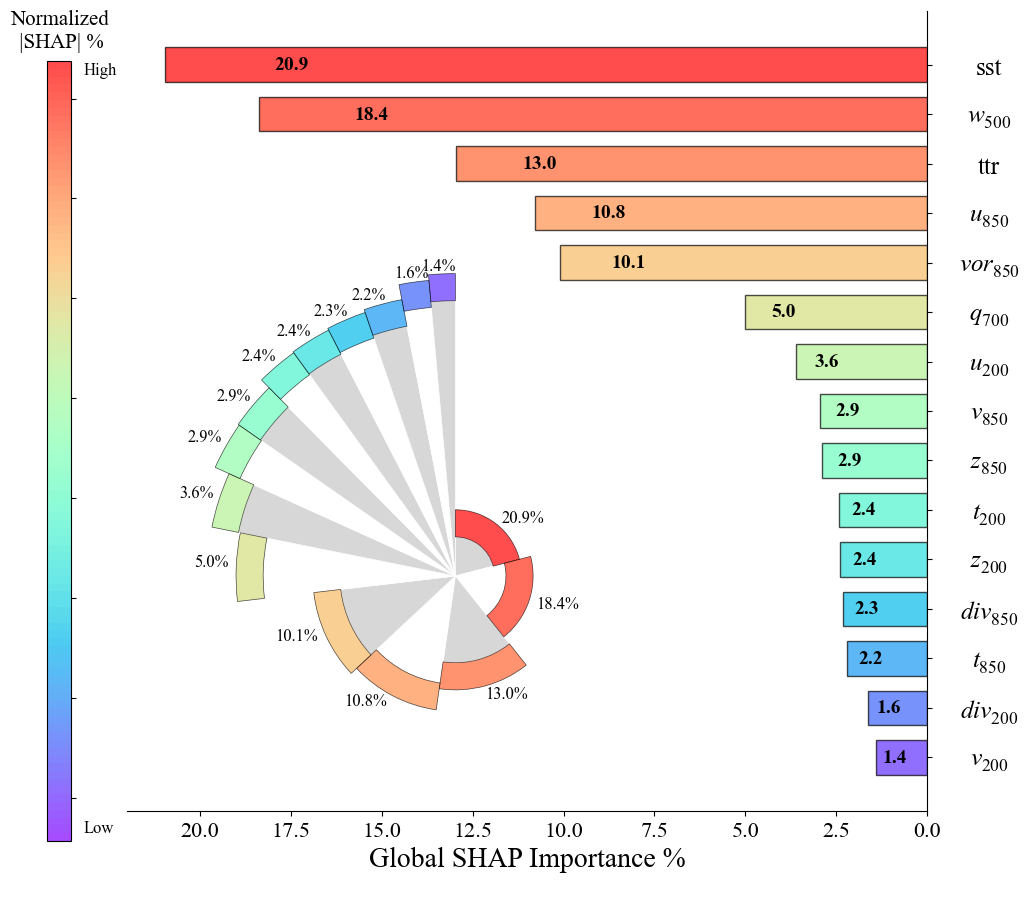

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
plt.rcParams['font.family'] = 'Times New Roman'
# === 模拟你的数据（请替换为真实的） ===
sorted_names = [
    "q_700",
    "w_500",
    "u_850",
    "u_200",
    "v_850",
    "v_200",
    "vor_850",
    "div_850",
    "div_200",
    "sst",
    "ttr",
    "t_200",
    "t_850",
    "z_200",
    "z_850",
]
# 转换为 LaTeX 下标格式（使用 $ 包围）
def to_latex_subscript(name):
    if '_' in name:
        prefix, num = name.split('_')
        return f"${prefix}_{{{num}}}$"  # 如 q_{700}
    return name

sorted_names = [to_latex_subscript(name) for name in sorted_names]
sorted_values = np.array([5.011351, 18.356464, 10.770328, 3.605004, 2.937626, 1.418769, 10.109071, 2.324172, 1.62583, 20.940069, 12.96846, 2.439904, 2.206441, 2.399462, 2.887049])
# 获取按值从大到小排序的索引
indices = np.argsort(sorted_values)[::-1]

# 重新排序
sorted_names = [sorted_names[i] for i in indices]
sorted_values = sorted_values[indices]

# 打印结果
for name, value in zip(sorted_names, sorted_values):
    print(f"{name}: {value}")
# === 计算百分比与颜色 ===
percentages = sorted_values / np.sum(sorted_values) * 100
cmap = get_cmap("rainbow",100)
norm = Normalize(vmin=np.min(percentages), vmax=np.max(percentages))
colors = [cmap(norm(p)) for p in np.linspace(np.max(percentages),np.min(percentages),16)]

# === 创建画布 ===
fig = plt.figure(figsize=(16, 10))

# === 左侧柱状图 ===
ax_bar = fig.add_axes([0.45, 0.1, 0.5, 0.8])
ax_bar.barh(range(len(sorted_values)), sorted_values, color=colors, height=0.7,alpha = 0.7, edgecolor='black')
ax_bar.set_yticks(range(len(sorted_names)))
ax_bar.set_yticklabels(sorted_names, fontsize=18, fontname = 'Times New Roman',ha = 'center',x = 1.065)
ax_bar.tick_params(axis = 'x', labelsize = 16,labelfontfamily = 'Times New Roman')
ax_bar.invert_yaxis()
ax_bar.yaxis.tick_right()  # 把刻度线移动到右侧
ax_bar.yaxis.set_label_position("right")  # 把标签文字也移到右侧
ax_bar.set_xlabel("Global SHAP Importance %", fontsize=20,fontname = 'Times New Roman')

ax_bar.spines[['top', 'left']].set_visible(False)
plt.gca().invert_xaxis()

for i, v in enumerate(sorted_values):
    ax_bar.text(v*6/7, i, f"{v:.1f}", va='center',fontsize=14,fontname = 'Times New Roman',color = 'black',fontweight='bold')

# === 右侧嵌入玫瑰图 ===
# 嵌套在柱状图区域内的右上角
ax_polar = fig.add_axes([0.38, 0.01, 0.55, 0.65], polar=True)
ax_polar.patch.set_alpha(0)
# 基本参数
percentages = sorted_values / np.sum(sorted_values) * 100
num_vars = len(sorted_names)

# 每个扇区角度（占比越大 → 角度越宽）
angles = (percentages / np.sum(percentages)) * 2 * np.pi
angle_starts = np.cumsum(np.concatenate([[0], angles[:-1]]))  # 起始角度

# 内圈高度（黑白条）
inner_radii = (np.exp((100-percentages)/10) / np.max(percentages)) /50

# 外圈高度设置为统一环厚度（模拟“彩色边缘环”效果）
outer_thickness = 1.8  # 控制环厚度
outer_radii = np.full_like(inner_radii, outer_thickness)

# === 内圈：黑白交替条 ===
for i in range(num_vars):
    color = 'lightgray' if i % 2 == 0 else 'white'
    ax_polar.bar(angle_starts[i], inner_radii[i], width=angles[i],
                 color=color, align='edge', edgecolor='white', alpha=0.9, linewidth=0.5)

# === 外圈：等厚度环状切片（颜色条） ===
n = 0
for i in range(num_vars):
    ax_polar.bar(angle_starts[i], outer_radii[i], width=angles[i],
                 bottom=inner_radii[i], color=colors[i], edgecolor='black',
                 linewidth=0.5, align='edge',alpha = 0.7)
    if n > 12 :
    # === 标签文字（更贴近条形边缘） ===
        angle_mid = angle_starts[i] + angles[i] *4/ 5 + 0.02
        text_radius = inner_radii[i] + outer_radii[i] + 0.5  # 更靠近图形
        ha = 'left' if 0 <= angle_mid <= np.pi else 'right'
        rotation = np.degrees(angle_mid)
        ax_polar.text(angle_mid, text_radius, f"{percentages[i]:.1f}%",
                    ha=ha, va='center', fontsize=12,fontname = 'Times New Roman'
                    )
    else:
        angle_mid = angle_starts[i] + angles[i] / 2 + 0.02
        text_radius = inner_radii[i] + outer_radii[i] + 0.5  # 更靠近图形
        ha = 'left' if 0 <= angle_mid <= np.pi else 'right'
        rotation = np.degrees(angle_mid)
        ax_polar.text(angle_mid, text_radius, f"{percentages[i]:.1f}%",
                    ha=ha, va='center', fontsize=12,fontname = 'Times New Roman'
                    )
    n +=1
# 极坐标图美化设置
ax_polar.set_yticklabels([])
ax_polar.set_xticklabels([])
ax_polar.spines['polar'].set_visible(False)
ax_polar.grid(False)
ax_polar.set_theta_zero_location('N')
ax_polar.set_theta_direction(-1)
ax_polar.set_ylim(0, np.max(inner_radii + outer_radii) + 1.5)

from matplotlib.colorbar import ColorbarBase

# === 添加 colorbar 的 axes，放在最左侧 ===
cbar_ax = fig.add_axes([0.40, 0.07, 0.015, 0.78])  # [left, bottom, width, height]

# 创建 colorbar 本体
cbar = ColorbarBase(cbar_ax, cmap=cmap, norm=norm, orientation='vertical', alpha=0.7)
cbar_ax.set_yticklabels([])  # 不显示刻度值

# === 添加 High / Low 标签 ===
cbar_ax.text(1.5, 20.72, 'High', fontsize=12, ha='left', va='center', fontname='Times New Roman')
cbar_ax.text(1.5, 1.75, 'Low', fontsize=12, ha='left', va='center', fontname='Times New Roman')

# === 添加 colorbar 说明文字 ===
cbar_ax.set_title('Normalized\n |SHAP| %', fontsize=15, fontname='Times New Roman', pad=10)
cbar.ax.tick_params(labelsize=12, labelfontfamily='Times New Roman')  # 隐藏刻度线

# === 保存图像 ===
plt.savefig("C:/Users/sysu/Desktop/tp_reconstruction/results/gradient_shap_result_plot/coastline_global_shap_jet_style.png", dpi=600, bbox_inches='tight')
plt.show()


shap小提琴图

SHAP root: C:\Users\sysu\Desktop\tp_reconstruction\gradient_shap
Data root: C:\Users\sysu\Desktop\tp_reconstruction\data\test
Lead times: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
Use common dates: True
Points per sample: 1
Leading  0: 738 SHAP files
Leading  2: 726 SHAP files
Leading  4: 714 SHAP files
Leading  6: 702 SHAP files
Leading  8: 690 SHAP files
Leading 10: 678 SHAP files
Leading 12: 666 SHAP files
Leading 14: 654 SHAP files
Leading 16: 642 SHAP files
Leading 18: 630 SHAP files
Leading 20: 618 SHAP files

Use 618 common target dates for all lead times.



Leading  0: 100%|██████████| 618/618 [00:02<00:00, 292.24it/s, input=20190831~20190831, points=1, target=20190831]


Leading  0: contribution sum=100.000000%


Leading  2: 100%|██████████| 618/618 [00:02<00:00, 216.76it/s, input=20190829~20190830, points=1, target=20190831]


Leading  2: contribution sum=100.000000%


...

Plotting SHAP beeswarm:  87%|████████▋ | 13/15 [00:16<00:02,  1.30s/it]

   w_500 color range: P5=-0.0851021, P95=0.240426


Plotting SHAP beeswarm:  93%|█████████▎| 14/15 [00:18<00:01,  1.30s/it]

     sst color range: P5=-0.197408, P95=0.0902069


Plotting SHAP beeswarm: 100%|██████████| 15/15 [00:18<00:00,  1.24s/it]


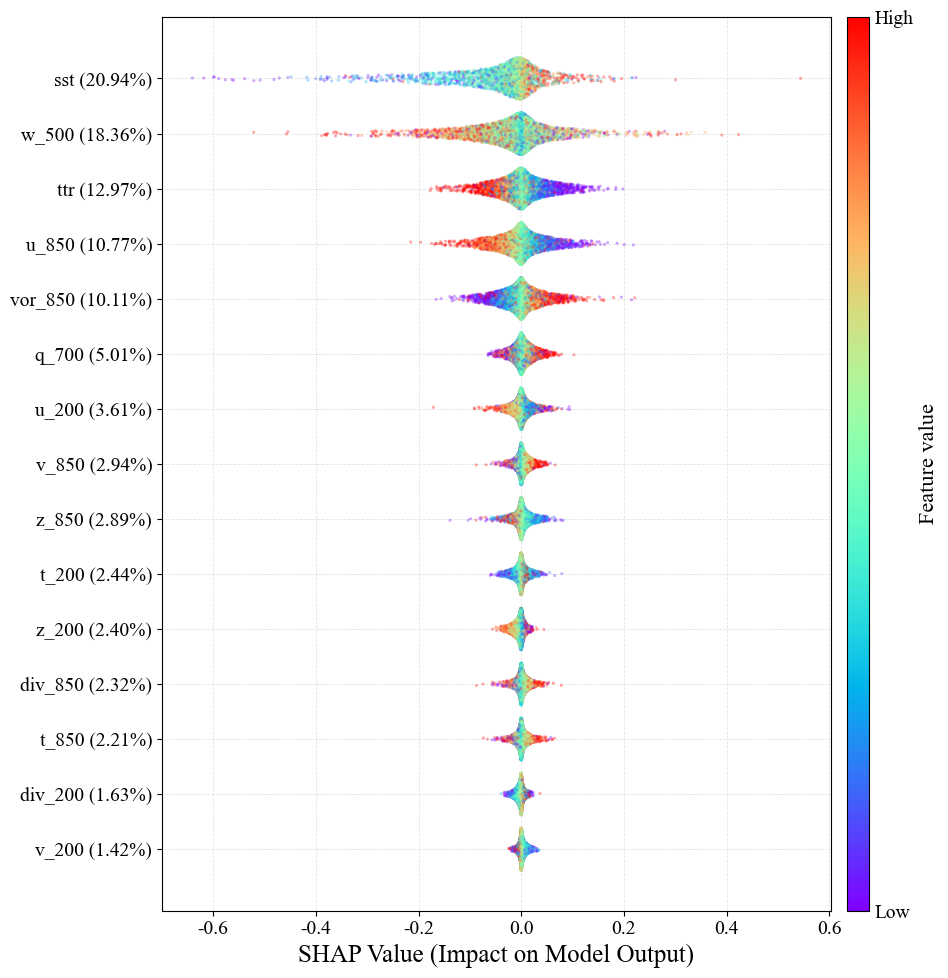


Figure saved to: C:\Users\sysu\Desktop\tp_reconstruction\results\gradient_shap_result_plot\all_leadtime_shap_violin.png


In [2]:
import os
import re
import glob
from datetime import datetime, timedelta
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from tqdm import tqdm


# ============================================================
# 1. 参数设置
# ============================================================

# Gradient SHAP结果根目录
# 内部结构：
# gradient_shap/
# ├── leading0/
# ├── leading2/
# ├── ...
# └── leading28/
SHAP_ROOT_DIR = r"C:\Users\sysu\Desktop\tp_reconstruction\gradient_shap"

# 测试数据根目录
# 内部包含q_700、w_500、sst等变量文件夹
DATA_ROOT_DIR = r"C:\Users\sysu\Desktop\tp_reconstruction\data\test"

# 图片保存路径
SAVE_PATH = (
    r"C:\Users\sysu\Desktop\tp_reconstruction"
    r"\results\gradient_shap_result_plot"
    r"\all_leadtime_shap_violin.png"
)

# 提前时间
LEAD_TIMES = list(range(0, 21, 2))

# SHAP结果文件夹命名
LEADING_FOLDER_FORMAT = "leading{}"

# 15个变量的通道顺序
FEATURE_NAMES = [
    "q_700",
    "w_500",
    "u_850",
    "u_200",
    "v_850",
    "v_200",
    "vor_850",
    "div_850",
    "div_200",
    "sst",
    "ttr",
    "t_200",
    "t_850",
    "z_200",
    "z_850",
]

# 对应的数据文件夹名称
# 按你的config，Z_200和Z_850文件夹首字母为大写
FEATURE_FOLDERS = {
    "q_700": "q_700",
    "w_500": "w_500",
    "u_850": "u_850",
    "u_200": "u_200",
    "v_850": "v_850",
    "v_200": "v_200",
    "vor_850": "vor_850",
    "div_850": "div_850",
    "div_200": "div_200",
    "sst": "sst",
    "ttr": "ttr",
    "t_200": "t_200",
    "t_850": "t_850",
    "z_200": "Z_200",
    "z_850": "Z_850",
}

SST_CHANNEL_INDEX = FEATURE_NAMES.index("sst")

EXPECTED_HEIGHT = 31
EXPECTED_WIDTH = 21
EXPECTED_SHAP_SHAPE = (15, 31, 21)

# 是否仅使用所有leading共同存在的目标日期
USE_COMMON_DATES = True

# SHAP绘图时的放大倍数，保留原代码中的×1000
SHAP_SCALE = 1000

# 每个SHAP文件最多抽取多少空间格点用于小提琴图
# None表示每个文件使用全部31×21=651个格点
# 数据量太大时可改成100或200
POINTS_PER_SAMPLE = 1

# SST陆地零值判断阈值
SST_ZERO_EPS = 0.0

# 是否在纵轴标签中显示总体贡献百分比
SHOW_CONTRIBUTION_PERCENT = True

# 小提琴图参数，保持原方法
BINS = 100
JITTER_SCALE = 2.5
SCATTER_SIZE = 5
SCATTER_ALPHA = 0.35

# KDE宽度参数
MIN_HALF_WIDTH = 0.03
MAX_HALF_WIDTH = 0.38
KDE_BW_METHOD = "scott"

RANDOM_SEED = 42
FIG_DPI = 600


# ============================================================
# 2. 绘图设置
# ============================================================

np.random.seed(RANDOM_SEED)
random_generator = np.random.default_rng(RANDOM_SEED)

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 14
plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 3. 获取SHAP文件
# ============================================================

def get_shap_files(folder_path):
    """获取文件夹内全部YYYYMMDD.npy文件。"""
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(f"SHAP folder does not exist: {folder_path}")

    filename_pattern = re.compile(r"^\d{8}\.npy$")
    file_dict = {}

    for file_path in glob.glob(os.path.join(folder_path, "*.npy")):
        file_name = os.path.basename(file_path)

        if not filename_pattern.match(file_name):
            continue

        target_date = os.path.splitext(file_name)[0]
        file_dict[target_date] = file_path

    return dict(sorted(file_dict.items()))


def get_all_leading_files():
    """读取所有leading文件夹中的SHAP文件。"""
    all_files = {}

    for lead_time in LEAD_TIMES:
        folder_path = os.path.join(
            SHAP_ROOT_DIR,
            LEADING_FOLDER_FORMAT.format(lead_time),
        )

        file_dict = get_shap_files(folder_path)

        if not file_dict:
            raise RuntimeError(f"No SHAP files found in: {folder_path}")

        all_files[lead_time] = file_dict
        print(f"Leading {lead_time:>2}: {len(file_dict)} SHAP files")

    return all_files


# ============================================================
# 4. 获取当前模型实际使用的输入日期
# ============================================================

def get_input_dates(target_date, lead_time):
    """
    新leading定义：

    lead=0：
        X(t) -> TP(t)

    lead=L>0：
        mean[X(t-L), ..., X(t-1)] -> TP(t)
    """
    target_datetime = datetime.strptime(target_date, "%Y%m%d")

    if lead_time == 0:
        return [target_date]

    input_dates = []

    for days_before in range(lead_time, 0, -1):
        input_datetime = target_datetime - timedelta(days=days_before)
        input_dates.append(input_datetime.strftime("%Y%m%d"))

    return input_dates


# ============================================================
# 5. 读取单个二维数组
# ============================================================

def load_2d_array(file_path, variable_name, date_name):
    """读取并检查一个31×21数组。"""
    if not os.path.isfile(file_path):
        raise FileNotFoundError(
            f"Missing input file: variable={variable_name}, "
            f"date={date_name}, path={file_path}"
        )

    array = np.load(file_path, allow_pickle=False)
    array = np.squeeze(array)

    expected_shape = (EXPECTED_HEIGHT, EXPECTED_WIDTH)

    if array.shape != expected_shape:
        raise ValueError(
            f"Invalid shape: variable={variable_name}, date={date_name}, "
            f"expected={expected_shape}, received={array.shape}, path={file_path}"
        )

    if not np.isfinite(array).all():
        raise ValueError(
            f"NaN or Inf found: variable={variable_name}, "
            f"date={date_name}, path={file_path}"
        )

    return array.astype(np.float32, copy=False)


# ============================================================
# 6. 读取一个样本的15通道模型输入
# ============================================================

def load_model_input_features(target_date, lead_time):
    """
    返回模型真正使用的输入特征。

    Shape:
        [15,31,21]

    lead=0：
        每个变量读取target_date当天数据。

    lead>0：
        每个变量分别对t-L到t-1求平均。
    """
    input_dates = get_input_dates(target_date, lead_time)
    feature_arrays = []

    for feature_name in FEATURE_NAMES:
        folder_name = FEATURE_FOLDERS[feature_name]
        temporal_arrays = []

        for input_date in input_dates:
            file_path = os.path.join(
                DATA_ROOT_DIR,
                folder_name,
                f"{input_date}.npy",
            )

            array = load_2d_array(
                file_path=file_path,
                variable_name=feature_name,
                date_name=input_date,
            )

            temporal_arrays.append(array)

        temporal_stack = np.stack(temporal_arrays, axis=0)

        # 与Dataset一致，每个变量单独沿时间维求平均
        feature_mean = np.mean(
            temporal_stack,
            axis=0,
            dtype=np.float32,
        )

        feature_arrays.append(feature_mean)

    features = np.stack(feature_arrays, axis=0)

    if features.shape != EXPECTED_SHAP_SHAPE:
        raise RuntimeError(
            f"Invalid feature shape for target={target_date}, "
            f"lead={lead_time}: {features.shape}"
        )

    return features, input_dates


# ============================================================
# 7. 单日贡献百分比
# ============================================================

def calculate_daily_contribution(shap_array, features, shap_file_path):
    """
    计算单个样本15个变量的相对贡献。

    普通变量：
        在完整31×21区域取平均绝对SHAP。

    SST：
        仅在当前模型输入SST不为0的海洋格点计算。

    最后在15个变量之间归一化为100%。
    """
    shap_array = np.asarray(shap_array, dtype=np.float32)
    shap_array = np.squeeze(shap_array)

    if shap_array.shape != EXPECTED_SHAP_SHAPE:
        raise ValueError(
            f"Invalid SHAP shape: expected={EXPECTED_SHAP_SHAPE}, "
            f"received={shap_array.shape}, path={shap_file_path}"
        )

    if not np.isfinite(shap_array).all():
        raise ValueError(f"NaN or Inf found in SHAP file: {shap_file_path}")

    absolute_shap = np.abs(shap_array)

    # 普通变量在整个区域平均
    channel_importance = np.mean(
        absolute_shap,
        axis=(1, 2),
        dtype=np.float64,
    )

    # SST只使用海洋格点
    sst_input = features[SST_CHANNEL_INDEX]

    if SST_ZERO_EPS == 0:
        valid_sst_mask = sst_input != 0
    else:
        valid_sst_mask = np.abs(sst_input) > SST_ZERO_EPS

    valid_sst_mask &= np.isfinite(sst_input)

    if not np.any(valid_sst_mask):
        raise ValueError(f"No valid SST ocean pixels: {shap_file_path}")

    channel_importance[SST_CHANNEL_INDEX] = np.mean(
        absolute_shap[SST_CHANNEL_INDEX][valid_sst_mask],
        dtype=np.float64,
    )

    total_importance = np.sum(channel_importance)

    if not np.isfinite(total_importance) or total_importance <= 0:
        raise ValueError(f"Invalid total SHAP importance: {shap_file_path}")

    relative_contribution = (
        channel_importance / total_importance * 100.0
    )

    return relative_contribution


# ============================================================
# 8. 读取全部lead并构建小提琴图数据
# ============================================================

def collect_all_data(all_files):
    """
    同时完成：

    1. 计算每个lead的平均贡献；
    2. 计算所有lead的总体平均贡献；
    3. 拼接小提琴图所需的SHAP值和特征值。

    返回：
        shap_values: [samples,15]
        features: [samples,15]
        overall_contribution: [15]
    """
    if USE_COMMON_DATES:
        date_sets = [
            set(file_dict.keys())
            for file_dict in all_files.values()
        ]

        common_dates = sorted(set.intersection(*date_sets))

        if not common_dates:
            raise RuntimeError(
                "No common target dates exist across all leading folders."
            )

        print(
            f"\nUse {len(common_dates)} common target dates "
            f"for all lead times.\n"
        )
    else:
        common_dates = None

    all_shap_rows = []
    all_feature_rows = []
    lead_mean_contributions = []

    for lead_time in LEAD_TIMES:
        file_dict = all_files[lead_time]

        if USE_COMMON_DATES:
            current_dates = common_dates
        else:
            current_dates = sorted(file_dict.keys())

        daily_contributions = []

        progress_bar = tqdm(
            current_dates,
            desc=f"Leading {lead_time:>2}",
            dynamic_ncols=True,
        )

        for target_date in progress_bar:
            shap_file_path = file_dict[target_date]

            shap_array = np.load(
                shap_file_path,
                allow_pickle=False,
            ).astype(np.float32)

            shap_array = np.squeeze(shap_array)

            if shap_array.shape != EXPECTED_SHAP_SHAPE:
                raise ValueError(
                    f"Invalid SHAP shape: {shap_file_path}, "
                    f"received={shap_array.shape}"
                )

            features, input_dates = load_model_input_features(
                target_date=target_date,
                lead_time=lead_time,
            )

            daily_contribution = calculate_daily_contribution(
                shap_array=shap_array,
                features=features,
                shap_file_path=shap_file_path,
            )

            daily_contributions.append(daily_contribution)

            # [15,31,21] -> [651,15]
            shap_rows = shap_array.reshape(15, -1).T
            feature_rows = features.reshape(15, -1).T

            # 可选：每个日期随机抽取部分空间格点
            if (
                POINTS_PER_SAMPLE is not None
                and POINTS_PER_SAMPLE < shap_rows.shape[0]
            ):
                selected_indices = random_generator.choice(
                    shap_rows.shape[0],
                    size=POINTS_PER_SAMPLE,
                    replace=False,
                )

                shap_rows = shap_rows[selected_indices]
                feature_rows = feature_rows[selected_indices]

            all_shap_rows.append(
                shap_rows.astype(np.float32, copy=False)
            )

            all_feature_rows.append(
                feature_rows.astype(np.float32, copy=False)
            )

            progress_bar.set_postfix(
                target=target_date,
                input=f"{input_dates[0]}~{input_dates[-1]}",
                points=shap_rows.shape[0],
            )

        daily_contributions = np.stack(
            daily_contributions,
            axis=0,
        )

        # 先在当前lead内部对日期平均
        lead_mean_contribution = np.mean(
            daily_contributions,
            axis=0,
        )

        lead_mean_contributions.append(
            lead_mean_contribution
        )

        print(
            f"Leading {lead_time:>2}: "
            f"contribution sum="
            f"{lead_mean_contribution.sum():.6f}%"
        )

    # [lead数量,15]
    lead_mean_contributions = np.stack(
        lead_mean_contributions,
        axis=0,
    )

    # 每个lead权重相同
    overall_contribution = np.mean(
        lead_mean_contributions,
        axis=0,
    )

    # 消除浮点误差，确保总和为100%
    overall_contribution = (
        overall_contribution
        / overall_contribution.sum()
        * 100.0
    )

    # 拼接所有日期、所有lead、所有空间格点
    shap_values = np.concatenate(
        all_shap_rows,
        axis=0,
    )

    features = np.concatenate(
        all_feature_rows,
        axis=0,
    )

    if shap_values.shape != features.shape:
        raise RuntimeError(
            f"SHAP and feature shape mismatch: "
            f"{shap_values.shape} vs {features.shape}"
        )

    if shap_values.shape[1] != 15:
        raise RuntimeError(
            f"Expected 15 features, received {shap_values.shape}"
        )

    return (
        shap_values,
        features,
        overall_contribution,
        lead_mean_contributions,
    )


# ============================================================
# 9. 绘制小提琴/蜂群图
# ============================================================

# def plot_violin_beeswarm(shap_values, features, overall_contribution):
#     """
#     绘制SHAP小提琴/蜂群图。

#     每个变量独立进行颜色映射：
#     - 第5百分位作为vmin；
#     - 第95百分位作为vmax；
#     - 超出范围的值截断至色带两端。

#     最终共享colorbar仅表示Low到High，
#     不显示不同变量各自的实际特征数值。
#     """
#     shap_values = shap_values.astype(np.float32) * SHAP_SCALE
#     features = features.astype(np.float32)

#     num_features = len(FEATURE_NAMES)

#     # 按全部lead time的平均贡献从小到大排序
#     # pos=0位于最下方，所以贡献最大的变量位于最上方
#     sorted_indices = np.argsort(overall_contribution)

#     if SHOW_CONTRIBUTION_PERCENT:
#         sorted_names = [
#             f"{FEATURE_NAMES[idx]} ({overall_contribution[idx]:.2f}%)"
#             for idx in sorted_indices
#         ]
#     else:
#         sorted_names = [FEATURE_NAMES[idx] for idx in sorted_indices]

#     print("\nOverall contribution sorted from high to low:")
#     for idx in sorted_indices[::-1]:
#         print(f"{FEATURE_NAMES[idx]:>8s}: {overall_contribution[idx]:.6f}%")

#     fig, ax = plt.subplots(figsize=(10, 10))
#     cmap = cm.rainbow

#     iterator = tqdm(
#         enumerate(sorted_indices),
#         total=num_features,
#         desc="Plotting SHAP violin",
#     )

#     for pos, idx in iterator:
#         shap_vals = shap_values[:, idx]
#         feature_vals = features[:, idx]

#         # 排除NaN和Inf
#         valid_mask = np.isfinite(shap_vals) & np.isfinite(feature_vals)

#         # SST排除陆地零值
#         if idx == SST_CHANNEL_INDEX:
#             if SST_ZERO_EPS == 0:
#                 valid_mask &= feature_vals != 0
#             else:
#                 valid_mask &= np.abs(feature_vals) > SST_ZERO_EPS

#         shap_vals = shap_vals[valid_mask]
#         feature_vals = feature_vals[valid_mask]

#         if shap_vals.size == 0:
#             raise RuntimeError(
#                 f"No valid plotting samples for {FEATURE_NAMES[idx]}"
#             )

#         # ====================================================
#         # 每个变量单独计算第5和第95百分位颜色范围
#         # ====================================================
#         feature_vmin, feature_vmax = np.percentile(
#             feature_vals,
#             [5, 95],
#         )

#         # 极端情况下该变量所有值几乎相同，避免Normalize除以0
#         if not np.isfinite(feature_vmin) or not np.isfinite(feature_vmax):
#             raise RuntimeError(
#                 f"Invalid percentile range for {FEATURE_NAMES[idx]}"
#             )

#         if feature_vmax <= feature_vmin:
#             feature_min = float(np.min(feature_vals))
#             feature_max = float(np.max(feature_vals))

#             if feature_max > feature_min:
#                 feature_vmin = feature_min
#                 feature_vmax = feature_max
#             else:
#                 epsilon = max(abs(feature_min) * 1e-6, 1e-6)
#                 feature_vmin = feature_min - epsilon
#                 feature_vmax = feature_max + epsilon

#         # clip=True：
#         # 小于5百分位的值映射到最低颜色；
#         # 大于95百分位的值映射到最高颜色
#         feature_norm = Normalize(
#             vmin=feature_vmin,
#             vmax=feature_vmax,
#             clip=True,
#         )

#         print(
#             f"{FEATURE_NAMES[idx]:>8s} color range: "
#             f"P5={feature_vmin:.6g}, P95={feature_vmax:.6g}"
#         )

#         # ====================================================
#         # 保持原有小提琴密度与jitter方法
#         # ====================================================
#         counts, bin_edges = np.histogram(
#             shap_vals,
#             bins=BINS,
#             density=False,
#         )

#         bin_indices = np.digitize(
#             shap_vals,
#             bin_edges,
#         ) - 1

#         bin_indices = np.clip(
#             bin_indices,
#             0,
#             BINS - 1,
#         )

#         freq_density = counts[bin_indices]

#         freq_norm = (
#             freq_density - freq_density.min()
#         ) / (
#             freq_density.max()
#             - freq_density.min()
#             + 1e-8
#         )

#         current_num_samples = shap_vals.shape[0]

#         jitter = (
#             np.random.rand(current_num_samples) - 0.5
#         ) * JITTER_SCALE * np.log10(1.2 + freq_norm)

#         y = np.ones(current_num_samples) * pos + jitter

#         # 每个变量使用自己独立的5%—95%颜色范围
#         colors = cmap(feature_norm(feature_vals))

#         ax.scatter(
#             shap_vals,
#             y,
#             color=colors,
#             s=SCATTER_SIZE,
#             alpha=SCATTER_ALPHA,
#             edgecolors="none",
#         )

#     # ========================================================
#     # 坐标轴设置
#     # ========================================================
#     ax.set_yticks(np.arange(num_features))
#     ax.set_yticklabels(
#         sorted_names,
#         fontsize=16,
#         fontname="Times New Roman",
#     )

#     ax.set_xlabel(
#         "SHAP Value (Impact on Model Output)",
#         fontsize=18,
#         fontname="Times New Roman",
#     )

#     ax.tick_params(
#         axis="both",
#         labelsize=14,
#         labelfontfamily="Times New Roman",
#     )

#     ax.grid(axis="x", linestyle="--", alpha=0.5)
#     ax.grid(axis="y", linestyle="--", alpha=0.5)
#     ax.set_axisbelow(True)

#     # SHAP=0参考线
#     ax.axvline(
#         x=0,
#         color="black",
#         linewidth=0.8,
#         alpha=0.7,
#     )

#     # ========================================================
#     # 通用相对颜色条
#     # ========================================================
#     # 各变量实际范围不同，因此colorbar只表示相对Low—High
#     colorbar_norm = Normalize(vmin=0, vmax=1)
#     scalar_mappable = plt.cm.ScalarMappable(
#         cmap=cmap,
#         norm=colorbar_norm,
#     )
#     scalar_mappable.set_array([])

#     colorbar = plt.colorbar(
#         scalar_mappable,
#         ax=ax,
#         aspect=40,
#         pad=0.02,
#     )

#     # 不显示具体数值，只标Low和High
#     colorbar.set_ticks([0, 1])
#     colorbar.set_ticklabels(["Low", "High"])

#     colorbar.set_label(
#         "Feature value",
#         fontsize=16,
#         fontname="Times New Roman",
#     )

#     colorbar.ax.tick_params(
#         length=0,
#         labelsize=14,
#         labelfontfamily="Times New Roman",
#     )

#     plt.tight_layout()

#     save_dir = os.path.dirname(SAVE_PATH)
#     if save_dir:
#         os.makedirs(save_dir, exist_ok=True)

#     plt.savefig(
#         SAVE_PATH,
#         dpi=FIG_DPI,
#         bbox_inches="tight",
#     )

#     plt.show()
#     plt.close(fig)

#     print(f"\nFigure saved to: {SAVE_PATH}")
def plot_violin_beeswarm(shap_values, features, overall_contribution):
    """
    绘制SHAP蜂群图。

    纵向宽度使用Gaussian KDE估计：
    - 数据密集的位置更宽；
    - 数据稀疏的位置更窄；
    - 使用平方根压缩密度差异，使形状更自然。

    每个变量独立使用自身特征值的第5和第95百分位
    作为颜色映射范围。
    """
    shap_values = shap_values.astype(np.float32) * SHAP_SCALE
    features = features.astype(np.float32)

    num_features = len(FEATURE_NAMES)

    # 从小到大排序，因此贡献最大的变量显示在最上方
    sorted_indices = np.argsort(overall_contribution)

    if SHOW_CONTRIBUTION_PERCENT:
        sorted_names = [
            f"{FEATURE_NAMES[idx]} ({overall_contribution[idx]:.2f}%)"
            for idx in sorted_indices
        ]
    else:
        sorted_names = [FEATURE_NAMES[idx] for idx in sorted_indices]

    print("\nContribution sorted from high to low:")
    for idx in sorted_indices[::-1]:
        print(f"{FEATURE_NAMES[idx]:>8s}: {overall_contribution[idx]:.6f}%")

    fig, ax = plt.subplots(figsize=(10, 10))
    cmap = cm.rainbow

    iterator = tqdm(
        enumerate(sorted_indices),
        total=num_features,
        desc="Plotting SHAP beeswarm",
    )

    for pos, idx in iterator:
        shap_vals = shap_values[:, idx]
        feature_vals = features[:, idx]

        # 排除NaN和Inf
        valid_mask = np.isfinite(shap_vals) & np.isfinite(feature_vals)

        # SST排除陆地零值
        if idx == SST_CHANNEL_INDEX:
            if SST_ZERO_EPS == 0:
                valid_mask &= feature_vals != 0
            else:
                valid_mask &= np.abs(feature_vals) > SST_ZERO_EPS

        shap_vals = shap_vals[valid_mask]
        feature_vals = feature_vals[valid_mask]

        if shap_vals.size == 0:
            raise RuntimeError(
                f"No valid plotting samples for {FEATURE_NAMES[idx]}"
            )

        # ====================================================
        # 每个变量单独计算颜色范围
        # ====================================================
        feature_vmin, feature_vmax = np.percentile(feature_vals, [5, 95])

        if not np.isfinite(feature_vmin) or not np.isfinite(feature_vmax):
            raise RuntimeError(
                f"Invalid color range for {FEATURE_NAMES[idx]}"
            )

        # 防止变量数值全部相同
        if feature_vmax <= feature_vmin:
            feature_min = float(np.min(feature_vals))
            feature_max = float(np.max(feature_vals))

            if feature_max > feature_min:
                feature_vmin = feature_min
                feature_vmax = feature_max
            else:
                epsilon = max(abs(feature_min) * 1e-6, 1e-6)
                feature_vmin = feature_min - epsilon
                feature_vmax = feature_max + epsilon

        feature_norm = Normalize(
            vmin=feature_vmin,
            vmax=feature_vmax,
            clip=True,
        )

        print(
            f"{FEATURE_NAMES[idx]:>8s} color range: "
            f"P5={feature_vmin:.6g}, P95={feature_vmax:.6g}"
        )

        # ====================================================
        # 使用Gaussian KDE计算SHAP值局部密度
        # ====================================================
        if shap_vals.size >= 3 and np.std(shap_vals) > 1e-12:
            try:
                kde = gaussian_kde(
                    shap_vals.astype(np.float64),
                    bw_method=KDE_BW_METHOD,
                )

                density = kde(
                    shap_vals.astype(np.float64)
                )

            except np.linalg.LinAlgError:
                density = np.ones(
                    shap_vals.shape[0],
                    dtype=np.float64,
                )
        else:
            density = np.ones(
                shap_vals.shape[0],
                dtype=np.float64,
            )

        density_min = np.min(density)
        density_max = np.max(density)

        if density_max > density_min:
            density_norm = (
                density - density_min
            ) / (
                density_max - density_min
            )
        else:
            density_norm = np.ones_like(density)

        # 使用平方根而不是log：
        # 保留密度差异，同时避免中心区域过度膨胀
        width_factor = np.sqrt(density_norm)

        half_width = (
            MIN_HALF_WIDTH
            + (MAX_HALF_WIDTH - MIN_HALF_WIDTH)
            * width_factor
        )

        # 每个点在对应局部宽度内随机分布
        random_offset = (
            random_generator.random(shap_vals.shape[0]) * 2.0
            - 1.0
        )

        jitter = random_offset * half_width
        y = np.full(shap_vals.shape[0], pos, dtype=np.float64) + jitter

        # 每个变量使用自身的5%—95%颜色范围
        colors = cmap(feature_norm(feature_vals))

        ax.scatter(
            shap_vals,
            y,
            c=colors,
            s=SCATTER_SIZE,
            alpha=SCATTER_ALPHA,
            edgecolors="none",
            linewidths=0,
            rasterized=True,
        )

    # ========================================================
    # 坐标轴设置
    # ========================================================
    ax.set_yticks(np.arange(num_features))
    ax.set_yticklabels(
        sorted_names,
        fontsize=16,
        fontname="Times New Roman",
    )

    ax.set_xlabel(
        "SHAP Value (Impact on Model Output)",
        fontsize=18,
        fontname="Times New Roman",
    )

    ax.tick_params(
        axis="both",
        labelsize=14,
        labelfontfamily="Times New Roman",
    )

    ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.set_axisbelow(True)

    # 不绘制x=0黑色竖线

    # ========================================================
    # 共享相对颜色条
    # ========================================================
    colorbar_norm = Normalize(vmin=0, vmax=1)
    scalar_mappable = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=colorbar_norm,
    )
    scalar_mappable.set_array([])

    colorbar = plt.colorbar(
        scalar_mappable,
        ax=ax,
        aspect=40,
        pad=0.02,
    )

    colorbar.set_ticks([0, 1])
    colorbar.set_ticklabels(["Low", "High"])

    colorbar.set_label(
        "Feature value",
        fontsize=16,
        fontname="Times New Roman",
    )

    colorbar.ax.tick_params(
        length=0,
        labelsize=14,
        labelfontfamily="Times New Roman",
    )

    plt.tight_layout()

    save_dir = os.path.dirname(SAVE_PATH)
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    plt.savefig(
        SAVE_PATH,
        dpi=FIG_DPI,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(f"\nFigure saved to: {SAVE_PATH}")


# ============================================================
# 10. 主程序
# ============================================================

def main():
    if len(FEATURE_NAMES) != 15:
        raise ValueError(
            f"FEATURE_NAMES must contain 15 variables, "
            f"received {len(FEATURE_NAMES)}"
        )

    if not os.path.isdir(SHAP_ROOT_DIR):
        raise FileNotFoundError(
            f"SHAP_ROOT_DIR does not exist: {SHAP_ROOT_DIR}"
        )

    if not os.path.isdir(DATA_ROOT_DIR):
        raise FileNotFoundError(
            f"DATA_ROOT_DIR does not exist: {DATA_ROOT_DIR}"
        )

    print("=" * 70)
    print(f"SHAP root: {SHAP_ROOT_DIR}")
    print(f"Data root: {DATA_ROOT_DIR}")
    print(f"Lead times: {LEAD_TIMES}")
    print(f"Use common dates: {USE_COMMON_DATES}")
    print(f"Points per sample: {POINTS_PER_SAMPLE}")
    print("=" * 70)

    all_files = get_all_leading_files()

    (
        shap_values,
        features,
        overall_contribution,
        lead_mean_contributions,
    ) = collect_all_data(all_files)

    print(f"\nCollected SHAP shape: {shap_values.shape}")
    print(f"Collected feature shape: {features.shape}")

    print("\nOverall contribution list in original channel order (%):")
    print([
        round(float(value), 6)
        for value in overall_contribution
    ])

    plot_violin_beeswarm(
        shap_values=shap_values,
        features=features,
        overall_contribution=overall_contribution,
    )


if __name__ == "__main__":
    main()

Selected lead time: 20
SHAP root: C:\Users\sysu\Desktop\tp_reconstruction\gradient_shap
Data root: C:\Users\sysu\Desktop\tp_reconstruction\data\test
Points per sample: 10
Output path: C:\Users\sysu\Desktop\tp_reconstruction\results\gradient_shap_result_plot\leading20_shap_violin.png
Leading 20: 618 SHAP files


Leading 20: 100%|██████████| 618/618 [00:20<00:00, 30.15it/s, input=20190811~20190830, points=10, target=20190831]



Collected SHAP shape: (6180, 15)
Collected feature shape: (6180, 15)

Contribution list in original 15-channel order (%):
[4.339402, 6.472579, 8.527178, 5.092712, 2.578839, 1.982492, 5.735372, 2.57799, 3.052131, 40.367863, 5.638008, 2.657518, 2.616964, 3.722262, 4.638691]
Contribution sum: 100.000000%

Leading 20 contribution sorted from high to low:
     sst: 40.367863%
   u_850: 8.527178%
   w_500: 6.472579%
 vor_850: 5.735372%
     ttr: 5.638008%
   u_200: 5.092712%
   z_850: 4.638691%
   q_700: 4.339402%
   z_200: 3.722262%
 div_200: 3.052131%
   t_200: 2.657518%
   t_850: 2.616964%
   v_850: 2.578839%
 div_850: 2.577990%
   v_200: 1.982492%


Plotting SHAP violin: 100%|██████████| 15/15 [00:00<00:00, 639.04it/s]


   v_200 color range: P5=-0.239101, P95=0.0720066
 div_850 color range: P5=-0.0610555, P95=0.146129
   v_850 color range: P5=-0.0610555, P95=0.146129
   t_850 color range: P5=-0.0610555, P95=0.146129
   t_200 color range: P5=-0.239101, P95=0.0720066
 div_200 color range: P5=-0.239101, P95=0.0720066
   z_200 color range: P5=-0.069117, P95=0.210067
   q_700 color range: P5=-0.15995, P95=0.2137
   z_850 color range: P5=-0.12775, P95=0.0685563
   u_200 color range: P5=-0.189816, P95=0.248216
     ttr color range: P5=-0.22042, P95=0.219432
 vor_850 color range: P5=-0.147314, P95=0.128261
   w_500 color range: P5=-0.0379234, P95=0.196861
   u_850 color range: P5=-0.206476, P95=0.249487
     sst color range: P5=-0.166076, P95=0.0546372


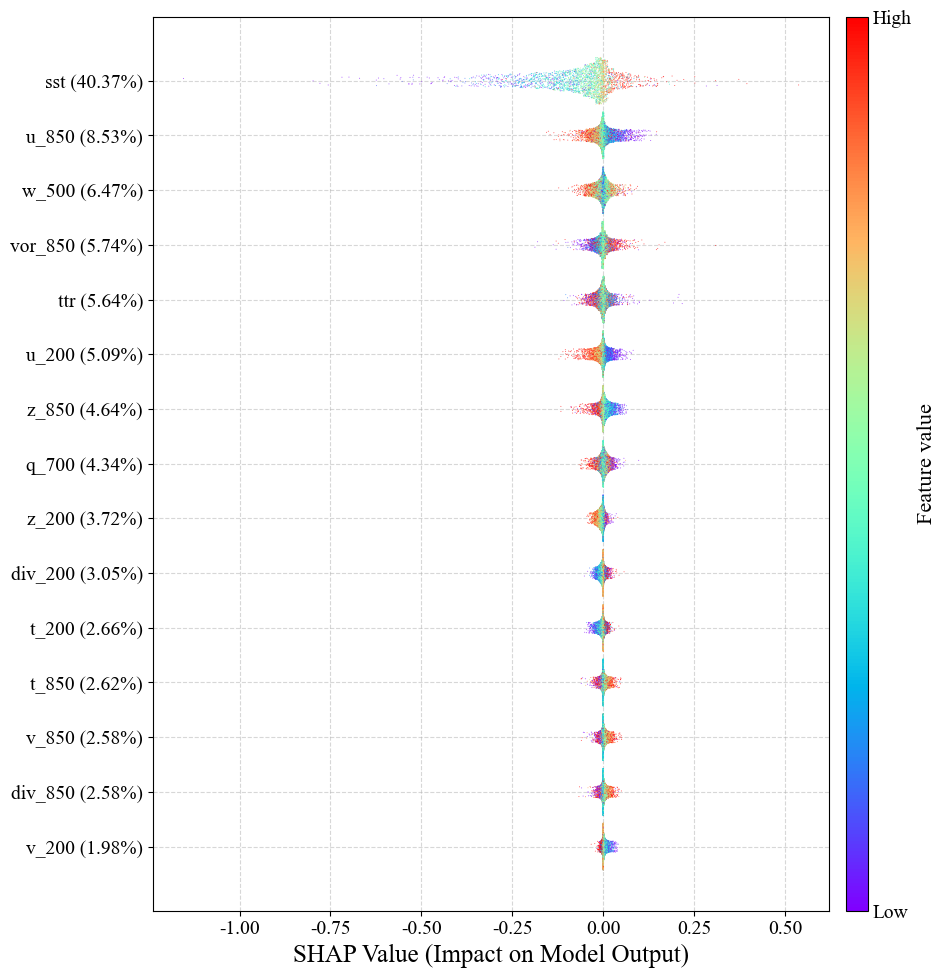


Figure saved to: C:\Users\sysu\Desktop\tp_reconstruction\results\gradient_shap_result_plot\leading20_shap_violin.png


In [10]:
import os
import re
import glob
from datetime import datetime, timedelta

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from tqdm import tqdm


# ============================================================
# 1. 参数设置
# ============================================================

# 指定本次要绘制的leading time
SELECTED_LEAD_TIME = 20

# Gradient SHAP结果根目录
# 内部结构：
# gradient_shap/
# ├── leading0/
# ├── leading2/
# ├── ...
# └── leading28/
SHAP_ROOT_DIR = r"C:\Users\sysu\Desktop\tp_reconstruction\gradient_shap"

# 测试数据根目录
DATA_ROOT_DIR = r"C:\Users\sysu\Desktop\tp_reconstruction\data\test"

# 图片输出目录
OUTPUT_DIR = (
    r"C:\Users\sysu\Desktop\tp_reconstruction"
    r"\results\gradient_shap_result_plot"
)

# 图片名称会自动包含leading time
SAVE_PATH = os.path.join(
    OUTPUT_DIR,
    f"leading{SELECTED_LEAD_TIME}_shap_violin.png",
)

LEADING_FOLDER_FORMAT = "leading{}"

# SHAP文件中的15个通道顺序
FEATURE_NAMES = [
    "q_700",
    "w_500",
    "u_850",
    "u_200",
    "v_850",
    "v_200",
    "vor_850",
    "div_850",
    "div_200",
    "sst",
    "ttr",
    "t_200",
    "t_850",
    "z_200",
    "z_850",
]

# 对应的数据文件夹名称
FEATURE_FOLDERS = {
    "q_700": "q_700",
    "w_500": "w_500",
    "u_850": "u_850",
    "u_200": "u_200",
    "v_850": "v_850",
    "v_200": "v_200",
    "vor_850": "vor_850",
    "div_850": "div_850",
    "div_200": "div_200",
    "sst": "sst",
    "ttr": "ttr",
    "t_200": "t_200",
    "t_850": "t_850",
    "z_200": "Z_200",
    "z_850": "Z_850",
}

SST_CHANNEL_INDEX = FEATURE_NAMES.index("sst")

EXPECTED_HEIGHT = 31
EXPECTED_WIDTH = 21
EXPECTED_SHAP_SHAPE = (15, 31, 21)

# SHAP值绘图时的放大倍数
SHAP_SCALE = 1000.0

# 每个日期随机抽取多少个空间点
# None表示使用全部651个点
POINTS_PER_SAMPLE = 10

# SST陆地值
SST_ZERO_EPS = 0.0

# 是否在变量名称后显示贡献百分比
SHOW_CONTRIBUTION_PERCENT = True

# 蜂群图参数
BINS = 100
JITTER_SCALE = 2.5
SCATTER_SIZE = 0.5
SCATTER_ALPHA = 0.7

# 各变量独立颜色范围的百分位
COLOR_PERCENTILE_LOW = 5
COLOR_PERCENTILE_HIGH = 95

RANDOM_SEED = 42
FIG_DPI = 600


# ============================================================
# 2. 全局设置
# ============================================================

np.random.seed(RANDOM_SEED)
random_generator = np.random.default_rng(RANDOM_SEED)

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 14
plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 3. 获取指定leading的SHAP文件
# ============================================================

def get_shap_files(folder_path):
    """获取文件夹内全部YYYYMMDD.npy文件。"""
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(
            f"SHAP folder does not exist: {folder_path}"
        )

    filename_pattern = re.compile(r"^\d{8}\.npy$")
    file_dict = {}

    for file_path in glob.glob(os.path.join(folder_path, "*.npy")):
        file_name = os.path.basename(file_path)

        if not filename_pattern.match(file_name):
            continue

        target_date = os.path.splitext(file_name)[0]
        file_dict[target_date] = file_path

    file_dict = dict(sorted(file_dict.items()))

    if not file_dict:
        raise RuntimeError(
            f"No valid SHAP files found in: {folder_path}"
        )

    return file_dict


def get_selected_lead_files(lead_time):
    """只读取指定leading time文件夹。"""
    folder_path = os.path.join(
        SHAP_ROOT_DIR,
        LEADING_FOLDER_FORMAT.format(lead_time),
    )

    file_dict = get_shap_files(folder_path)

    print(
        f"Leading {lead_time}: "
        f"{len(file_dict)} SHAP files"
    )

    return file_dict


# ============================================================
# 4. 根据leading获取实际输入日期
# ============================================================

def get_input_dates(target_date, lead_time):
    """
    lead=0：
        X(t) -> TP(t)

    lead=L>0：
        mean[X(t-L), ..., X(t-1)] -> TP(t)
    """
    target_datetime = datetime.strptime(
        target_date,
        "%Y%m%d",
    )

    if lead_time == 0:
        return [target_date]

    input_dates = []

    for days_before in range(lead_time, 0, -1):
        input_datetime = (
            target_datetime
            - timedelta(days=days_before)
        )

        input_dates.append(
            input_datetime.strftime("%Y%m%d")
        )

    return input_dates


# ============================================================
# 5. 读取二维变量数据
# ============================================================

def load_2d_array(file_path, variable_name, date_name):
    """读取并检查一个31×21数组。"""
    if not os.path.isfile(file_path):
        raise FileNotFoundError(
            f"Missing input file: variable={variable_name}, "
            f"date={date_name}, path={file_path}"
        )

    array = np.load(
        file_path,
        allow_pickle=False,
    )

    array = np.squeeze(array)

    expected_shape = (
        EXPECTED_HEIGHT,
        EXPECTED_WIDTH,
    )

    if array.shape != expected_shape:
        raise ValueError(
            f"Invalid shape: variable={variable_name}, "
            f"date={date_name}, expected={expected_shape}, "
            f"received={array.shape}, path={file_path}"
        )

    if not np.isfinite(array).all():
        raise ValueError(
            f"NaN or Inf found: variable={variable_name}, "
            f"date={date_name}, path={file_path}"
        )

    return array.astype(
        np.float32,
        copy=False,
    )


# ============================================================
# 6. 读取一个样本实际使用的15通道输入
# ============================================================

def load_model_input_features(target_date, lead_time):
    """
    返回模型真正使用的输入特征，形状为[15,31,21]。

    lead=0：
        使用目标日期当天的各变量。

    lead>0：
        每个变量分别对t-L到t-1求平均。
    """
    input_dates = get_input_dates(
        target_date,
        lead_time,
    )

    feature_arrays = []

    for feature_name in FEATURE_NAMES:
        folder_name = FEATURE_FOLDERS[
            feature_name
        ]

        temporal_arrays = []

        for input_date in input_dates:
            file_path = os.path.join(
                DATA_ROOT_DIR,
                folder_name,
                f"{input_date}.npy",
            )

            array = load_2d_array(
                file_path=file_path,
                variable_name=feature_name,
                date_name=input_date,
            )

            temporal_arrays.append(array)

        temporal_stack = np.stack(
            temporal_arrays,
            axis=0,
        )

        feature_mean = np.mean(
            temporal_stack,
            axis=0,
            dtype=np.float32,
        )

        feature_arrays.append(
            feature_mean
        )

    features = np.stack(
        feature_arrays,
        axis=0,
    )

    if features.shape != EXPECTED_SHAP_SHAPE:
        raise RuntimeError(
            f"Invalid feature shape for "
            f"target={target_date}, "
            f"lead={lead_time}: {features.shape}"
        )

    return features, input_dates


# ============================================================
# 7. 计算单日贡献百分比
# ============================================================

def calculate_daily_contribution(
    shap_array,
    features,
    shap_file_path,
):
    """
    普通变量：
        在完整31×21区域计算平均绝对SHAP。

    SST：
        仅在输入SST不为0的海洋格点计算。

    最后将15个变量归一化为100%。
    """
    shap_array = np.asarray(
        shap_array,
        dtype=np.float32,
    )

    shap_array = np.squeeze(
        shap_array
    )

    if shap_array.shape != EXPECTED_SHAP_SHAPE:
        raise ValueError(
            f"Invalid SHAP shape: "
            f"expected={EXPECTED_SHAP_SHAPE}, "
            f"received={shap_array.shape}, "
            f"path={shap_file_path}"
        )

    if not np.isfinite(shap_array).all():
        raise ValueError(
            f"NaN or Inf found in SHAP file: "
            f"{shap_file_path}"
        )

    absolute_shap = np.abs(
        shap_array
    )

    channel_importance = np.mean(
        absolute_shap,
        axis=(1, 2),
        dtype=np.float64,
    )

    # SST排除陆地
    sst_input = features[
        SST_CHANNEL_INDEX
    ]

    if SST_ZERO_EPS == 0:
        valid_sst_mask = sst_input != 0
    else:
        valid_sst_mask = (
            np.abs(sst_input)
            > SST_ZERO_EPS
        )

    valid_sst_mask &= np.isfinite(
        sst_input
    )

    if not np.any(valid_sst_mask):
        raise ValueError(
            f"No valid SST ocean pixels: "
            f"{shap_file_path}"
        )

    channel_importance[
        SST_CHANNEL_INDEX
    ] = np.mean(
        absolute_shap[
            SST_CHANNEL_INDEX
        ][valid_sst_mask],
        dtype=np.float64,
    )

    total_importance = np.sum(
        channel_importance
    )

    if (
        not np.isfinite(total_importance)
        or total_importance <= 0
    ):
        raise ValueError(
            f"Invalid total SHAP importance: "
            f"{shap_file_path}"
        )

    relative_contribution = (
        channel_importance
        / total_importance
        * 100.0
    )

    return relative_contribution


# ============================================================
# 8. 收集指定leading的数据
# ============================================================

def collect_selected_lead_data(
    file_dict,
    lead_time,
):
    """
    只处理一个指定的leading time。

    返回
    -------
    shap_values : [N,15]
    features : [N,15]
    mean_contribution : [15]
    """
    all_shap_rows = []
    all_feature_rows = []
    daily_contributions = []

    target_dates = sorted(
        file_dict.keys()
    )

    progress_bar = tqdm(
        target_dates,
        desc=f"Leading {lead_time}",
        dynamic_ncols=True,
    )

    for target_date in progress_bar:
        shap_file_path = file_dict[
            target_date
        ]

        shap_array = np.load(
            shap_file_path,
            allow_pickle=False,
        ).astype(np.float32)

        shap_array = np.squeeze(
            shap_array
        )

        if shap_array.shape != EXPECTED_SHAP_SHAPE:
            raise ValueError(
                f"Invalid SHAP shape: "
                f"{shap_file_path}, "
                f"received={shap_array.shape}"
            )

        features, input_dates = (
            load_model_input_features(
                target_date=target_date,
                lead_time=lead_time,
            )
        )

        daily_contribution = (
            calculate_daily_contribution(
                shap_array=shap_array,
                features=features,
                shap_file_path=shap_file_path,
            )
        )

        daily_contributions.append(
            daily_contribution
        )

        # [15,31,21] -> [651,15]
        shap_rows = shap_array.reshape(
            15,
            -1,
        ).T

        feature_rows = features.reshape(
            15,
            -1,
        ).T

        # 每个日期随机抽样空间格点
        if (
            POINTS_PER_SAMPLE is not None
            and POINTS_PER_SAMPLE
            < shap_rows.shape[0]
        ):
            selected_indices = (
                random_generator.choice(
                    shap_rows.shape[0],
                    size=POINTS_PER_SAMPLE,
                    replace=False,
                )
            )

            shap_rows = shap_rows[
                selected_indices
            ]

            feature_rows = feature_rows[
                selected_indices
            ]

        all_shap_rows.append(
            shap_rows.astype(
                np.float32,
                copy=False,
            )
        )

        all_feature_rows.append(
            feature_rows.astype(
                np.float32,
                copy=False,
            )
        )

        progress_bar.set_postfix(
            target=target_date,
            input=(
                f"{input_dates[0]}~"
                f"{input_dates[-1]}"
            ),
            points=shap_rows.shape[0],
        )

    daily_contributions = np.stack(
        daily_contributions,
        axis=0,
    )

    # 当前leading下，对所有日期平均
    mean_contribution = np.mean(
        daily_contributions,
        axis=0,
    )

    # 消除浮点误差
    mean_contribution = (
        mean_contribution
        / mean_contribution.sum()
        * 100.0
    )

    shap_values = np.concatenate(
        all_shap_rows,
        axis=0,
    )

    features = np.concatenate(
        all_feature_rows,
        axis=0,
    )

    if shap_values.shape != features.shape:
        raise RuntimeError(
            f"SHAP and feature shape mismatch: "
            f"{shap_values.shape} vs "
            f"{features.shape}"
        )

    if shap_values.shape[1] != 15:
        raise RuntimeError(
            f"Expected 15 channels, "
            f"received {shap_values.shape}"
        )

    return (
        shap_values,
        features,
        mean_contribution,
    )


# ============================================================
# 9. 绘制小提琴/蜂群图
# ============================================================

def plot_violin_beeswarm(
    shap_values,
    features,
    mean_contribution,
    lead_time,
):
    """
    按当前leading的平均贡献排序。

    每个变量独立使用：
        第5百分位作为vmin；
        第95百分位作为vmax。

    最终colorbar只显示Low和High。
    """
    shap_values = (
        shap_values.astype(np.float32)
        * SHAP_SCALE
    )

    features = features.astype(
        np.float32
    )

    num_features = len(
        FEATURE_NAMES
    )

    # 从小到大排序：
    # 贡献最大的变量显示在最上方
    sorted_indices = np.argsort(
        mean_contribution
    )

    if SHOW_CONTRIBUTION_PERCENT:
        sorted_names = [
            (
                f"{FEATURE_NAMES[idx]} "
                f"({mean_contribution[idx]:.2f}%)"
            )
            for idx in sorted_indices
        ]
    else:
        sorted_names = [
            FEATURE_NAMES[idx]
            for idx in sorted_indices
        ]

    print(
        f"\nLeading {lead_time} contribution "
        f"sorted from high to low:"
    )

    for idx in sorted_indices[::-1]:
        print(
            f"{FEATURE_NAMES[idx]:>8s}: "
            f"{mean_contribution[idx]:.6f}%"
        )

    fig, ax = plt.subplots(
        figsize=(10, 10)
    )

    cmap = cm.rainbow

    iterator = tqdm(
        enumerate(sorted_indices),
        total=num_features,
        desc="Plotting SHAP violin",
    )

    for pos, idx in iterator:
        shap_vals = shap_values[:, idx]
        feature_vals = features[:, idx]

        valid_mask = (
            np.isfinite(shap_vals)
            & np.isfinite(feature_vals)
        )

        # SST散点排除陆地
        if idx == SST_CHANNEL_INDEX:
            if SST_ZERO_EPS == 0:
                valid_mask &= (
                    feature_vals != 0
                )
            else:
                valid_mask &= (
                    np.abs(feature_vals)
                    > SST_ZERO_EPS
                )

        shap_vals = shap_vals[
            valid_mask
        ]

        feature_vals = feature_vals[
            valid_mask
        ]

        if shap_vals.size == 0:
            raise RuntimeError(
                f"No valid plotting samples for "
                f"{FEATURE_NAMES[idx]}"
            )

        # 每个变量单独计算5%和95%分位数
        feature_vmin, feature_vmax = (
            np.percentile(
                feature_vals,
                [
                    COLOR_PERCENTILE_LOW,
                    COLOR_PERCENTILE_HIGH,
                ],
            )
        )

        if (
            not np.isfinite(feature_vmin)
            or not np.isfinite(feature_vmax)
        ):
            raise RuntimeError(
                f"Invalid color range for "
                f"{FEATURE_NAMES[idx]}"
            )

        # 防止所有特征值相同
        if feature_vmax <= feature_vmin:
            feature_min = float(
                np.min(feature_vals)
            )

            feature_max = float(
                np.max(feature_vals)
            )

            if feature_max > feature_min:
                feature_vmin = feature_min
                feature_vmax = feature_max
            else:
                epsilon = max(
                    abs(feature_min) * 1e-6,
                    1e-6,
                )

                feature_vmin = (
                    feature_min - epsilon
                )

                feature_vmax = (
                    feature_max + epsilon
                )

        feature_norm = Normalize(
            vmin=feature_vmin,
            vmax=feature_vmax,
            clip=True,
        )

        print(
            f"{FEATURE_NAMES[idx]:>8s} "
            f"color range: "
            f"P{COLOR_PERCENTILE_LOW}="
            f"{feature_vmin:.6g}, "
            f"P{COLOR_PERCENTILE_HIGH}="
            f"{feature_vmax:.6g}"
        )

        # 保持原始直方统计方法
        counts, bin_edges = np.histogram(
            shap_vals,
            bins=BINS,
            density=False,
        )

        bin_indices = np.digitize(
            shap_vals,
            bin_edges,
        ) - 1

        bin_indices = np.clip(
            bin_indices,
            0,
            BINS - 1,
        )

        freq_density = counts[
            bin_indices
        ]

        freq_norm = (
            freq_density
            - freq_density.min()
        ) / (
            freq_density.max()
            - freq_density.min()
            + 1e-8
        )

        current_num_samples = (
            shap_vals.shape[0]
        )

        jitter = (
            np.random.rand(
                current_num_samples
            ) - 0.5
        ) * JITTER_SCALE * np.log10(
            1.2 + freq_norm
        )

        y = (
            np.ones(current_num_samples)
            * pos
            + jitter
        )

        colors = cmap(
            feature_norm(feature_vals)
        )

        ax.scatter(
            shap_vals,
            y,
            color=colors,
            s=SCATTER_SIZE,
            alpha=SCATTER_ALPHA,
            edgecolors="none",
        )

    # 坐标轴
    ax.set_yticks(
        np.arange(num_features)
    )

    ax.set_yticklabels(
        sorted_names,
        fontsize=16,
        fontname="Times New Roman",
    )

    ax.set_xlabel(
        "SHAP Value (Impact on Model Output)",
        fontsize=18,
        fontname="Times New Roman",
    )

    ax.tick_params(
        axis="both",
        labelsize=14,
        labelfontfamily="Times New Roman",
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.5,
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.5,
    )

    ax.set_axisbelow(True)

    # 不再绘制x=0黑色竖线

    # 共享相对颜色条
    colorbar_norm = Normalize(
        vmin=0,
        vmax=1,
    )

    scalar_mappable = (
        plt.cm.ScalarMappable(
            cmap=cmap,
            norm=colorbar_norm,
        )
    )

    scalar_mappable.set_array([])

    colorbar = plt.colorbar(
        scalar_mappable,
        ax=ax,
        aspect=40,
        pad=0.02,
    )

    colorbar.set_ticks([0, 1])
    colorbar.set_ticklabels(
        ["Low", "High"]
    )

    colorbar.set_label(
        "Feature value",
        fontsize=16,
        fontname="Times New Roman",
    )

    colorbar.ax.tick_params(
        length=0,
        labelsize=14,
        labelfontfamily="Times New Roman",
    )

    plt.tight_layout()

    os.makedirs(
        OUTPUT_DIR,
        exist_ok=True,
    )

    plt.savefig(
        SAVE_PATH,
        dpi=FIG_DPI,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(
        f"\nFigure saved to: "
        f"{SAVE_PATH}"
    )


# ============================================================
# 10. 主程序
# ============================================================

def main():
    if len(FEATURE_NAMES) != 15:
        raise ValueError(
            f"FEATURE_NAMES must contain "
            f"15 variables, received "
            f"{len(FEATURE_NAMES)}"
        )

    if SELECTED_LEAD_TIME < 0:
        raise ValueError(
            "SELECTED_LEAD_TIME must be "
            "greater than or equal to 0."
        )

    if not os.path.isdir(
        SHAP_ROOT_DIR
    ):
        raise FileNotFoundError(
            f"SHAP_ROOT_DIR does not exist: "
            f"{SHAP_ROOT_DIR}"
        )

    if not os.path.isdir(
        DATA_ROOT_DIR
    ):
        raise FileNotFoundError(
            f"DATA_ROOT_DIR does not exist: "
            f"{DATA_ROOT_DIR}"
        )

    print("=" * 70)
    print(
        f"Selected lead time: "
        f"{SELECTED_LEAD_TIME}"
    )
    print(
        f"SHAP root: "
        f"{SHAP_ROOT_DIR}"
    )
    print(
        f"Data root: "
        f"{DATA_ROOT_DIR}"
    )
    print(
        f"Points per sample: "
        f"{POINTS_PER_SAMPLE}"
    )
    print(
        f"Output path: "
        f"{SAVE_PATH}"
    )
    print("=" * 70)

    file_dict = get_selected_lead_files(
        SELECTED_LEAD_TIME
    )

    (
        shap_values,
        features,
        mean_contribution,
    ) = collect_selected_lead_data(
        file_dict=file_dict,
        lead_time=SELECTED_LEAD_TIME,
    )

    print(
        f"\nCollected SHAP shape: "
        f"{shap_values.shape}"
    )

    print(
        f"Collected feature shape: "
        f"{features.shape}"
    )

    print(
        "\nContribution list in original "
        "15-channel order (%):"
    )

    print([
        round(float(value), 6)
        for value in mean_contribution
    ])

    print(
        f"Contribution sum: "
        f"{mean_contribution.sum():.6f}%"
    )

    plot_violin_beeswarm(
        shap_values=shap_values,
        features=features,
        mean_contribution=mean_contribution,
        lead_time=SELECTED_LEAD_TIME,
    )


if __name__ == "__main__":
    main()

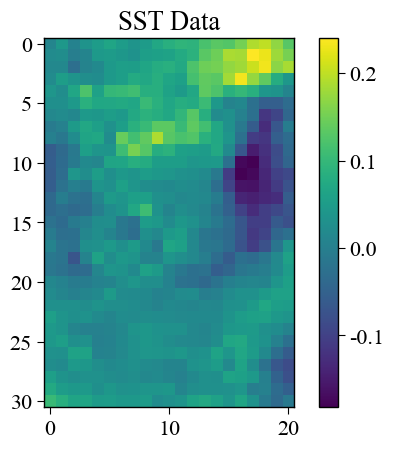

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# data_list = glob.glob("C:/Users/sysu/Desktop/tp_reconstruction/data/train/sst/*.npy")
# max_list = []
# for data in data_list:
#     max_value = np.max(np.load(data))
#     if max_value == 1:
#         print(data)
#     max_list.append(max_value)
# print(max(max_list))
data = np.load("C:/Users/sysu/Desktop/tp_reconstruction/train_results/miso_dilated_se/leading0/19800505.npy")[::-1]
plt.imshow(data, cmap='viridis')
plt.colorbar()
plt.title('SST Data')
plt.show()
